# UFC PREDICTION ALGORITHM

##### A project made by Giovanni Ditaranto 

Decision Science 2025/26 Uniba

In [42]:
# !pip install jupyter_contrib_nbextensions
# !jupyter contrib nbextension install --user
# !jupyter nbextension enable python-markdown/main

# %%

### Loading the datasets and checking on them

In [43]:
import pandas as pd
import numpy as np
fights    = pd.read_csv('data/ufc_fight_results.csv')
stats     = pd.read_csv('data/ufc_fight_stats.csv')
details   = pd.read_csv('data/ufc_fighter_details.csv')
tott      = pd.read_csv('data/ufc_fighter_tott.csv')
events    = pd.read_csv('data/ufc_event_details.csv')

In [44]:
fights.head(2)

,EVENT,BOUT,OUTCOME,WEIGHTCLASS,METHOD,ROUND,TIME,TIME FORMAT,REFEREE,DETAILS,URL
0,UFC Fight Night: Allen vs. Costa,Arnold Allen vs. Melquizael Costa,W/L,Featherweight Bout,Decision - Unanimous,5,5:00,5 Rnd (5-5-5-5-5),Chris Tognoni,Eric Colon 45 - 50.David Lethaby 45 - 50.Sal D...,http://ufcstats.com/fight-details/e4aa60812489...
1,UFC Fight Night: Allen vs. Costa,Dooho Choi vs. Daniel Santos,W/L,Featherweight Bout,KO/TKO,2,4:29,3 Rnd (5-5-5),Kerry Hatley,Punch to Body At Distance,http://ufcstats.com/fight-details/fc1266e2892e...


In [45]:
events.head(2)

,EVENT,URL,DATE,LOCATION
0,UFC Fight Night: Allen vs. Costa,http://ufcstats.com/event-details/73abb7a5c57f...,"May 16, 2026","Las Vegas, Nevada, USA"
1,UFC 328: Chimaev vs. Strickland,http://ufcstats.com/event-details/9eedac48b497...,"May 09, 2026","Newark, New Jersey, USA"


In [46]:
details.head(2)

,FIRST,LAST,NICKNAME,URL
0,Tom,Aaron,NaN,http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny,Abbadi,The Assassin,http://ufcstats.com/fighter-details/15df64c02b...


In [47]:
tott.head(2)

,FIGHTER,HEIGHT,WEIGHT,REACH,STANCE,DOB,URL
0,Tom Aaron,--,155 lbs.,--,NaN,"Jul 13, 1978",http://ufcstats.com/fighter-details/93fe7332d1...
1,Danny Abbadi,"5' 11""",155 lbs.,--,Orthodox,"Jul 03, 1983",http://ufcstats.com/fighter-details/15df64c02b...


In [48]:
print(f'fights columns: {fights.columns.tolist()}')
print(f'stats columns: {stats.columns.tolist()}')
print(f'events columns:{events.columns.tolist()}')
print(f'details columns: {details.columns.tolist()}')
print(f'tott columns: {tott.columns.tolist()}')
        

fights columns: ['EVENT', 'BOUT', 'OUTCOME', 'WEIGHTCLASS', 'METHOD', 'ROUND', 'TIME', 'TIME FORMAT', 'REFEREE', 'DETAILS', 'URL']
stats columns: ['EVENT', 'BOUT', 'ROUND', 'FIGHTER', 'KD', 'SIG.STR.', 'SIG.STR. %', 'TOTAL STR.', 'TD', 'TD %', 'SUB.ATT', 'REV.', 'CTRL', 'HEAD', 'BODY', 'LEG', 'DISTANCE', 'CLINCH', 'GROUND']
events columns:['EVENT', 'URL', 'DATE', 'LOCATION']
details columns: ['FIRST', 'LAST', 'NICKNAME', 'URL']
tott columns: ['FIGHTER', 'HEIGHT', 'WEIGHT', 'REACH', 'STANCE', 'DOB', 'URL']


# UFC PREDICTION
I scraped ufcstats.com for data, and got 5 datasets:
- Fights -> one row for every fight in an event (fight night) - with results (W/L or L/W) and method of finish + duration time and number of rounds 
- Stats -> for every round in a fight we have stats on how the fight went

- Details -> Nickname of the fighters, could be useful for merging w/ other datsets

- tott -> For every fighter we have a row w/ height, weight, reach and stance and date of birth

- Events -> one row for every event (fight nights) and date of the event

Now before joining them in a unique dataset I will check for NaN, problems or incongruence in names, since fighters don't have a unique ID, so I can't be certain.

After The join I will aggregate some columns to make features that will makes sense for the predictive algorithm, and will calculate some aggregated features



###  Before the JOIN

Data check and cleaning

In [49]:
# Check the latest and earliest events
print("Latest event:", events["DATE"].max())
print("Earliest event:", events["DATE"].min())

# Fixing the data type of the date column
print('Date column dtype: ')
events["DATE"].dtype
events["DATE"] = pd.to_datetime(events["DATE"], format="mixed")
print(events["DATE"].dtype)   # Should now be datetime64[ns]
print("Latest event:", events["DATE"].max())
print("Earliest event:", events["DATE"].min())


Latest event: September 29, 2012
Earliest event: April 01, 2009
Date column dtype: 
datetime64[ns]
Latest event: 2026-05-16 00:00:00
Earliest event: 1994-03-11 00:00:00


In [50]:
# print(f'nulli  fake: {(events == "---").sum()}')
# print(f'nulli  fake: {(fights == "---").sum()}')
# print(f'nulli  fake: {(stats == "---").sum()}')
# print(f'nulli  fake: {(details == "---").sum()}')
# print(f'nulli  fake: {(tott == "---").sum()}')

#REPLACING NULLI FAKES WITH NAN
events = events.replace("---", np.nan)
fights = fights.replace("---", np.nan)
stats = stats.replace("---", np.nan)
details = details.replace("---", np.nan)
tott = tott.replace("---", np.nan)


In [51]:
# CHECK FOR NAMES INCONGRUENCIES
listfighter = stats['FIGHTER'].value_counts()
print(listfighter)
    

FIGHTER
Rafael Dos Anjos    112
Max Holloway        111
Jim Miller          104
Frankie Edgar        99
Andrei Arlovski      95
                   ... 
Scott Fiedler         1
John Campetella       1
Julian Sanchez        1
Reza Nasri            1
Thomas Ramirez        1
Name: count, Length: 2678, dtype: int64


In [52]:
# null rate x Column
print(f'Null rate by column in events:\n{events.isna().mean().sort_values(ascending=False)}')
print(f'\nNull rate by column in fights:\n{fights.isna().mean().sort_values(ascending=False)}')
print(f'\nNull rate by column in stats:\n{stats.isna().mean().sort_values(ascending=False)}')
print(f'\nNull rate by column in details:\n{details.isna().mean().sort_values(ascending=False)}')
print(f'\nNull rate by column in tott:\n{tott.isna().mean().sort_values(ascending=False)}')

# events.isna().sum()[events.isna().sum() > 0]

# events.columns[events.isna().any()].tolist()



Null rate by column in events:
EVENT       0.0
URL         0.0
DATE        0.0
LOCATION    0.0
dtype: float64

Null rate by column in fights:
DETAILS        0.008964
REFEREE        0.002988
EVENT          0.000000
OUTCOME        0.000000
BOUT           0.000000
WEIGHTCLASS    0.000000
METHOD         0.000000
TIME           0.000000
ROUND          0.000000
TIME FORMAT    0.000000
URL            0.000000
dtype: float64

Null rate by column in stats:
TD %          0.465657
SIG.STR. %    0.006073
ROUND         0.001024
REV.          0.001024
CTRL          0.001024
KD            0.001024
FIGHTER       0.001024
SIG.STR.      0.001024
TOTAL STR.    0.001024
TD            0.001024
SUB.ATT       0.001024
LEG           0.001024
DISTANCE      0.001024
HEAD          0.001024
BODY          0.001024
CLINCH        0.001024
GROUND        0.001024
BOUT          0.000000
EVENT         0.000000
dtype: float64

Null rate by column in details:
NICKNAME    0.446274
FIRST       0.003782
LAST        0.000000


In [53]:
# for i in tott.columns['STANCE']:
#     print(i)


In [54]:
events.isna().mean().sort_values(ascending=False)


EVENT       0.0
URL         0.0
DATE        0.0
LOCATION    0.0
dtype: float64

In [55]:
tott.isna().mean().sort_values(ascending=False)


STANCE     0.202402
HEIGHT     0.000000
FIGHTER    0.000000
WEIGHT     0.000000
REACH      0.000000
DOB        0.000000
URL        0.000000
dtype: float64

In [56]:
details.isna().mean().sort_values(ascending=False)


NICKNAME    0.446274
FIRST       0.003782
LAST        0.000000
URL         0.000000
dtype: float64

In [57]:
stats.isna().mean().sort_values(ascending=False)


TD %          0.465657
SIG.STR. %    0.006073
ROUND         0.001024
REV.          0.001024
CTRL          0.001024
KD            0.001024
FIGHTER       0.001024
SIG.STR.      0.001024
TOTAL STR.    0.001024
TD            0.001024
SUB.ATT       0.001024
LEG           0.001024
DISTANCE      0.001024
HEAD          0.001024
BODY          0.001024
CLINCH        0.001024
GROUND        0.001024
BOUT          0.000000
EVENT         0.000000
dtype: float64

### |FIRST JOIN|

Join by fight id: master_df with columns [fight_id, date, fighter_r, fighter_b, winner], one row per fight.

fighter_r / fighter_b → split BOUT on " vs. " → first name = fighter_r (red corner), second = fighter_b (blue corner)
winner → 
- W/L → fighter_r won
- L/W → fighter_b won  
- D/D → "Draw"
- NC/NC → "No Contest"


 date → merge fights with events on EVENT (after stripping whitespace) → take DATE

In [58]:
# JOIN INTO master_df
# Strip whitespace from EVENT for clean merge
fights['EVENT'] = fights['EVENT'].str.strip()
events['EVENT'] = events['EVENT'].str.strip()

# Merge fights with events to get DATE
master_df = fights.merge(events[['EVENT', 'DATE']], on='EVENT', how='left')

# Parse BOUT to extract fighters (first = red corner, second = blue corner)
master_df[['fighter_r', 'fighter_b']] = master_df['BOUT'].str.split(' vs. ', expand=True)

# Create winner column based on OUTCOME
def get_winner(row):
    if row['OUTCOME'] == 'W/L':
        return row['fighter_r']
    elif row['OUTCOME'] == 'L/W':
        return row['fighter_b']
    elif row['OUTCOME'] == 'D/D':
        return 'Draw'
    elif row['OUTCOME'] == 'NC/NC':
        return 'No Contest'
    else:
        return None

master_df['winner'] = master_df.apply(get_winner, axis=1)

# Select and rename columns
master_df = master_df[['URL', 'DATE', 'EVENT', 'BOUT',
           'fighter_r', 'fighter_b', 'winner']].rename(columns={'URL': 'fight_id'})
print(f'master_df shape: {master_df.shape}')
print(master_df.head())
print(master_df['winner'].value_counts())


master_df shape: (8701, 7)
                                            fight_id       DATE  \
0  http://ufcstats.com/fight-details/e4aa60812489... 2026-05-16   
1  http://ufcstats.com/fight-details/fc1266e2892e... 2026-05-16   
2  http://ufcstats.com/fight-details/ecb7ff543dd4... 2026-05-16   
3  http://ufcstats.com/fight-details/57bd683efc79... 2026-05-16   
4  http://ufcstats.com/fight-details/a6ec8573a9d3... 2026-05-16   

                              EVENT                                      BOUT  \
0  UFC Fight Night: Allen vs. Costa         Arnold Allen vs. Melquizael Costa   
1  UFC Fight Night: Allen vs. Costa              Dooho Choi vs. Daniel Santos   
2  UFC Fight Night: Allen vs. Costa           Malcolm Wellmaker vs. Juan Diaz   
3  UFC Fight Night: Allen vs. Costa  Modestas Bukauskas vs. Christian Edwards   
4  UFC Fight Night: Allen vs. Costa            Timmy Cuamba vs. Benardo Sopaj   

            fighter_r          fighter_b              winner  
0        Arnold Alle

# Features Engineering on master_df

**ELO calculation**(per fight, in order):
$$expected_r = 1 / (1 + 10**((elo_b - elo_r) / 400))$$
$$expected_b = 1 - expected_r$$
$$new_elo_r = elo_r + K * (actual_r - expected_r)$$

$$actual_r = \begin{cases}\begin{alignat*} {4} 1&  &if &wins, \\&0.5 &if &draws, \\&0 &if &loses\end{alignat*}\end{cases}$$


| Category | Features | Source |
|---|---|---|
| **Career cumulative** | `num_fights`, `wins`, `losses`, `win_rate` | master_df |
| **Striking** | avg sig strikes landed/attempted per fight, avg KD, accuracy, head/body/leg ratio | stats |
| **Grappling** | avg TD landed/attempted, TD accuracy, avg control time, avg sub attempts, avg reversals | stats |
| **Striking defense** | avg opponent sig strikes absorbed per fight, striking defense % | stats (opponent) |
| **Grappling defense** | avg opponent TD per fight, TD defense % | stats (opponent) |
| **ELO** | rating (start 1500, K=32), expected score, rating change | computed per fight |
| **Opponent quality** | avg opponent ELO faced, avg opponent win rate | computed |
| **Recency** | days since last fight, fights in last 365d | master_df |
| **Rolling form (last 3/5)** | avg sig strikes, avg control time, finish rate in last N fights | computed |
| **Physical** | height, weight, reach, stance, age at fight time | tott + fight date |
| **Finish rate** | % of wins by KO/TKO, % by submission | fights (METHOD) |


than

| Category | Features | Source | How to calculate |
|---|---|---|---|
| **Opponent-adjusted striking** | striking score × opponent's striking defense weight | `stats` (opponent's sig strikes landed/attempted across their career) | Track each fighter's **striking defense** = `1 - (sig strikes absorbed / sig strikes faced)`. For fighter A's striking score: `A_sig_landed_per_fight × (1 + opp_striking_defense / avg_striking_defense)` — inflates when they perform against good defenders, deflates vs poor defenders |
| **Opponent-adjusted grappling** | TD score × opponent's TD defense weight | `stats` (opponent's TD landed/attempted across their career) | Track each fighter's **TD defense** = `1 - (opp_TD_landed / opp_TD_attempted)`. Same adjustment formula as striking |
| **Opponent ELO quality** | avg ELO, max ELO, min ELO of opponents faced | `master_df` ELO (computed chronologically) | For each fighter, track list of opponent ELOs faced. Pre-fight feature = `mean(opponent_elos)`, `max(opponent_elos)`, etc. |
| **Stance matchup** | same_stance, fighter_is_southpaw | `tott['STANCE']` (Orthodox/Southpaw/Switch/NaN) | Parse stance for both fighters. Flags: `same_stance` (1 if both same), `fighter_r_southpaw` (1 if fighter_r is southpaw). Southpaw vs orthodox gives a statistical edge |
| **Reach advantage** | reach_diff, reach_ratio | `tott['REACH']` (inches as string like `"72"`, `"--"`) | Parse `"--"` as NaN, convert to float. `reach_diff = fighter_r_reach - fighter_b_reach`. Same for height (`5' 11"` → 71 inches) |
| **Height advantage** | height_diff, height_ratio | `tott['HEIGHT']` (feet'inches string like `"5' 11\""`, `"--"`) | Parse `"5' 11\""` → total inches. `height_diff = r_height - b_height` |
| **Recent form (last 3/5)** | weighted avg sig strikes, TD, control time, finish rate over last N fights | `stats` + `fights['METHOD']` | Exponential or linear decay weights: `w = [0.5, 0.3, 0.2]` for last 3. Sum(stat × w) for each stat. Separate features for recent KO rate, recent sub rate |
| **Weight class change** | weight_class_changed, num_weight_class_changes | `fights['WEIGHTCLASS']` | Track fighter's previous fight's weight class. Flag = 1 if `current_wc != prev_wc`. Accumulate total changes over career |
| **Championship rounds** | num_championship_round_fights, pct_fights_to_round_4+ | `fights['ROUND']` (the round the fight ended in) + `fights['TIME FORMAT']` (e.g., `"5 Rnd (5-5-5-5-5)"`) | Count fights where `ROUND >= 4` or `TIME FORMAT` indicates 5-round main event. Shows experience in deep waters |


## Step 1: Parse & Clean Stats Table


**What:** Convert `stats` from per-round raw format into per-fighter-per-fight aggregates.


```python
# For each (EVENT, BOUT, FIGHTER) group — sum rounds together
# Unpack "X of Y" columns → landed, attempted, accuracy
# Unpack "M:SS" CTRL → total seconds
```

**Columns to parse:**
| Raw column | Parse as | Output columns |
|---|---|---|
| `SIG.STR.` (e.g. `"9 of 9"`) | split on `" of "` | `sig_landed`, `sig_attempted`, `sig_acc` |
| `TOTAL STR.` | split on `" of "` | `total_landed`, `total_attempted` |
| `HEAD`, `BODY`, `LEG` | split on `" of "` | `head_landed`, `body_landed`, `leg_landed` |
| `DISTANCE`, `CLINCH`, `GROUND` | split on `" of "` | `dist_landed`, `clinch_landed`, `ground_landed` |
| `TD` | split on `" of "` | `td_landed`, `td_attempted`, `td_acc` |
| `CTRL` | `"M:SS"` → seconds | `ctrl_sec` |
| `KD`, `SUB.ATT`, `REV.` | already float | kept as-is |
| `SIG.STR. %`, `TD %` | strip `"%"`, or drop (redundant with landed/attempted) | dropped |

**Output:** `fighter_fights` table — one row per (EVENT, BOUT, FIGHTER), with summed per-fight stats.

Then merge with `master_df` to get date + outcome per fighter:
```
fighter_fights = fighter_fights.merge(
    master_df[['fight_id', 'event', 'bout', 'date', 'fighter_r', 'fighter_b', 'winner']],
    on=['event', 'bout']
)
```

Also parse `tott` for static fighter info:
- `HEIGHT`: `"5' 11""` → total inches (or NaN)
- `WEIGHT`: `"155 lbs."` → int (strip `" lbs."`)
- `REACH`: `"72"` → int (or NaN for `"--"`)
- `STANCE`: keep as string (Orthodox/Southpaw/Switch)
- `DOB`: parse to datetime → compute age at fight date

Parse `fights['WEIGHTCLASS']` for weight class change tracking.

---


In [59]:
# ============================================================
# CELL 1: Parse & Clean Stats Table
# Unpack "X of Y" and "M:SS" formats, sum per (fight, fighter)
# ============================================================

def parse_x_of_y(series):
    split = series.str.split(' of ', expand=True)
    return pd.to_numeric(split[0], errors='coerce'), pd.to_numeric(split[1], errors='coerce')

def parse_ctrl(series):
    split = series.str.split(':', expand=True)
    minutes = pd.to_numeric(split[0], errors='coerce').fillna(0)
    seconds = pd.to_numeric(split[1], errors='coerce').fillna(0)
    return minutes * 60 + seconds

# Map raw stat columns to clean prefixes
col_map = {
    'SIG.STR.': 'sig', 'TOTAL STR.': 'total_str',
    'HEAD': 'head', 'BODY': 'body', 'LEG': 'leg',
    'DISTANCE': 'distance', 'CLINCH': 'clinch', 'GROUND': 'ground',
    'TD': 'td',
}

stats_clean = stats.copy()
for raw_col, prefix in col_map.items():
    landed, attempted = parse_x_of_y(stats_clean[raw_col])
    stats_clean[f'{prefix}_landed'] = landed
    stats_clean[f'{prefix}_attempted'] = attempted

stats_clean['ctrl_sec'] = parse_ctrl(stats_clean['CTRL'])
for col in ['KD', 'SUB.ATT', 'REV.']:
    stats_clean[col] = pd.to_numeric(stats_clean[col], errors='coerce').fillna(0)

# Aggregate per (EVENT, BOUT, FIGHTER) – sum across rounds
sum_cols = [f'{p}_{s}' for p in col_map.values() for s in ('landed', 'attempted')]
sum_cols += ['ctrl_sec', 'KD', 'SUB.ATT', 'REV.']

fighter_fights = (
    stats_clean.groupby(['EVENT', 'BOUT', 'FIGHTER'], as_index=False)[sum_cols]
    .sum()
)

fighter_fights['sig_acc'] = np.where(
    fighter_fights['sig_attempted'] > 0,
    fighter_fights['sig_landed'] / fighter_fights['sig_attempted'], np.nan)
fighter_fights['td_acc'] = np.where(
    fighter_fights['td_attempted'] > 0,
    fighter_fights['td_landed'] / fighter_fights['td_attempted'], np.nan)

print(f'fighter_fights shape: {fighter_fights.shape}')
print(f'Unique fighters: {fighter_fights["FIGHTER"].nunique()}')
print(f'Unique bouts:   {fighter_fights[["EVENT","BOUT"]].drop_duplicates().shape[0]}')

fighter_fights shape: (17358, 27)
Unique fighters: 2678
Unique bouts:   8679


In [60]:
# ============================================================
# CELL 2: Parse Physicals (tott) & Fight Metadata (fights)
# ============================================================

# --- Parse tott (fighter physicals) ---
tott_clean = tott.copy()

def parse_height(h):
    if pd.isna(h):
        return np.nan
    h = str(h).replace('"', '').strip()
    parts = h.split("' ")
    if len(parts) == 2:
        try:
            return int(parts[0]) * 12 + int(parts[1])
        except:
            return np.nan
    return np.nan

tott_clean['height_inches'] = tott_clean['HEIGHT'].apply(parse_height)
tott_clean['weight_lbs'] = pd.to_numeric(
    tott_clean['WEIGHT'].str.replace(' lbs.', '', regex=False), errors='coerce')
tott_clean['reach_inches'] = pd.to_numeric(tott_clean['REACH'].str.strip('"').str.strip(), errors='coerce')
tott_clean['DOB'] = pd.to_datetime(tott_clean['DOB'], format='mixed', errors='coerce')

# --- Parse fights (method categories + weight class) ---
def classify_method(m):
    if pd.isna(m):
        return np.nan
    ms = str(m).lower()
    if 'ko' in ms or 'tko' in ms:
        return 'KO/TKO'
    elif 'submission' in ms:
        return 'SUB'
    elif 'decision' in ms:
        return 'DEC'
    elif 'dq' in ms:
        return 'DQ'
    else:
        return 'OTHER'

fights['method_cat'] = fights['METHOD'].apply(classify_method)
fights['weight_class'] = fights['WEIGHTCLASS'].str.replace(' Bout', '', regex=False)
fights['max_rounds'] = (
    fights['TIME FORMAT'].str.extract(r'(\d+) Rnd', expand=False)
    .astype(float).fillna(3)
)
fights['champ_round_possible'] = fights['max_rounds'] >= 5

print('METHOD categories:')
print(fights['method_cat'].value_counts())
print()
print('Sample weight classes:')
print(fights['weight_class'].value_counts().head(10))

METHOD categories:
method_cat
DEC       4064
KO/TKO    2837
SUB       1685
OTHER       92
DQ          23
Name: count, dtype: int64

Sample weight classes:
weight_class
Lightweight            1402
Welterweight           1330
Middleweight           1092
Featherweight           828
Bantamweight            746
Heavyweight             711
Light Heavyweight       694
Flyweight               384
Women's Strawweight     346
Women's Flyweight       259
Name: count, dtype: int64


In [61]:
# ============================================================
# CELL 3: Build Chronological Fight–Fighter Table
# One row per (fight, fighter) with stats, physicals, metadata
# ============================================================

# Stack both fighters into tall format
chrono_rows = []
for _, row in master_df.iterrows():
    for role, fighter in [('r', row['fighter_r']), ('b', row['fighter_b'])]:
        chrono_rows.append({
            'fight_id': row['fight_id'],
            'date':      row['DATE'],
            'event':     row['EVENT'],
            'bout':      row['BOUT'],
            'fighter':   fighter,
            'role':      role,
            'opponent':  row['fighter_b'] if role == 'r' else row['fighter_r'],
            'winner_label': row['winner'],
        })

chrono = pd.DataFrame(chrono_rows)

# Rename for clean merges
ff = fighter_fights.rename(columns={'EVENT': 'event', 'BOUT': 'bout', 'FIGHTER': 'fighter'})
tc = tott_clean.rename(columns={'FIGHTER': 'fighter'})
fc = fights.rename(columns={'EVENT': 'event', 'BOUT': 'bout'})

# Merge stats, physicals, metadata
chrono = chrono.merge(ff, on=['event', 'bout', 'fighter'], how='left')
chrono = chrono.merge(
    tc[['fighter', 'height_inches', 'weight_lbs', 'reach_inches', 'STANCE', 'DOB']],
    on='fighter', how='left')
chrono = chrono.merge(
    fc[['event', 'bout', 'method_cat', 'weight_class', 'champ_round_possible']],
    on=['event', 'bout'], how='left')

# Fill missing stats with 0
stat_cols = [c for c in ff.columns if c not in ('event', 'bout', 'fighter')]
for c in stat_cols:
    chrono[c] = chrono[c].fillna(0)

# Determine per-fighter outcome
def get_outcome(row):
    w = row['winner_label']
    if w == 'Draw':
        return 'draw'
    elif w == 'No Contest':
        return 'no_contest'
    elif w == row['fighter']:
        return 'win'
    else:
        return 'loss'

chrono['outcome'] = chrono.apply(get_outcome, axis=1)

# Sort by date and assign fight index
chrono = chrono.sort_values('date').reset_index(drop=True)
fight_order = (
    chrono[['fight_id', 'date']].drop_duplicates('fight_id')
    .sort_values('date').reset_index(drop=True)
)
fight_order['fight_idx'] = range(len(fight_order))
chrono = chrono.merge(fight_order, on=['fight_id', 'date'], how='left')
chrono = chrono.sort_values('fight_idx').reset_index(drop=True)

print(f'chrono shape: {chrono.shape}')
print(f'Unique fights: {chrono["fight_id"].nunique()}, rows: {len(chrono)}')
print(f'Date range: {chrono["date"].min()}  →  {chrono["date"].max()}')

chrono shape: (17454, 42)
Unique fights: 8701, rows: 17454
Date range: 1994-03-11 00:00:00  →  2026-05-16 00:00:00


In [62]:
# ============================================================
# CELL 4: Feature Engine — Functions
# ============================================================

def init_fighter_history(name):
    return {
        'fighter': name,
        'num_fights': 0,
        'wins': 0, 'losses': 0, 'draws': 0,
        'ko_wins': 0, 'sub_wins': 0, 'dec_wins': 0,
        'sum_sig_landed': 0, 'sum_sig_attempted': 0,
        'sum_td_landed': 0, 'sum_td_attempted': 0,
        'sum_ctrl_sec': 0, 'sum_kd': 0, 'sum_sub_att': 0, 'sum_rev': 0,
        'sum_opp_sig_landed': 0, 'sum_opp_sig_attempted': 0,
        'sum_opp_td_landed': 0, 'sum_opp_td_attempted': 0,
        'opponent_elos': [], 'opponent_win_rates': [],
        'recent_fights': [],
        'last_fight_date': None,
        'last_weight_class': None,
        'num_weight_class_changes': 0,
        'champ_round_fights': 0,
        'elo': 1500,
    }

# Global stats tracker (running totals across all fights processed so far)
global_stats = {
    'sum_sig_landed': 0, 'sum_sig_attempted': 0,
    'sum_td_landed': 0, 'sum_td_attempted': 0,
    'sum_kd': 0, 'sum_ctrl_sec': 0, 'sum_sub_att': 0,
    'total_fights': 0,
}

def global_avg(key):
    if global_stats['total_fights'] == 0:
        return 0.01
    return global_stats[key] / global_stats['total_fights']

def compute_striking_score(hist):
    n = hist['num_fights']
    if n == 0:
        return np.nan
    vol  = (hist['sum_sig_landed'] / n) / max(global_avg('sum_sig_landed'), 0.01)
    acc  = (hist['sum_sig_landed'] / max(hist['sum_sig_attempted'], 1)) / max(global_avg('sum_sig_landed') / max(global_avg('sum_sig_attempted'), 0.01), 0.01)
    kd   = (hist['sum_kd'] / n) / max(global_avg('sum_kd'), 0.001)
    opp  = hist['sum_opp_sig_attempted']
    if opp > 0:
        my_d  = 1 - hist['sum_opp_sig_landed'] / opp
        g_d   = 1 - global_avg('sum_sig_landed') / max(global_avg('sum_sig_attempted'), 0.01)
        d_norm = my_d / max(g_d, 0.01)
    else:
        d_norm = 1.0
    return 0.30 * vol + 0.20 * acc + 0.15 * kd + 0.35 * d_norm

def compute_grappling_score(hist):
    n = hist['num_fights']
    if n == 0:
        return np.nan
    td_v = (hist['sum_td_landed'] / n) / max(global_avg('sum_td_landed'), 0.01)
    g_td_acc = global_avg('sum_td_landed') / max(global_avg('sum_td_attempted'), 0.01)
    td_a = (hist['sum_td_landed'] / max(hist['sum_td_attempted'], 1)) / max(g_td_acc, 0.01)
    ctrl = (hist['sum_ctrl_sec'] / n) / max(global_avg('sum_ctrl_sec'), 0.1)
    sub  = (hist['sum_sub_att'] / n) / max(global_avg('sum_sub_att'), 0.001)
    return 0.35 * td_v + 0.20 * td_a + 0.25 * ctrl + 0.20 * sub

def extract_features(hist, fighter_row):
    n  = hist['num_fights']
    dd = n == 0  # is_debut
    feats = {'is_debut': int(dd), 'num_fights': n}

    if dd:
        feats.update({
            'win_rate': np.nan, 'finish_rate': np.nan,
            'ko_rate': np.nan, 'sub_rate': np.nan,
            'sig_landed_per_fight': np.nan, 'sig_acc': np.nan,
            'sig_absorbed_per_fight': np.nan, 'striking_defense': np.nan,
            'td_landed_per_fight': np.nan, 'td_acc': np.nan,
            'td_defense': np.nan, 'ctrl_sec_per_fight': np.nan,
            'kd_per_fight': np.nan, 'sub_att_per_fight': np.nan,
            'avg_opp_elo': np.nan, 'avg_opp_win_rate': np.nan,
            'days_since_last_fight': np.nan,
            'champ_round_experience': 0,
            'weight_class_changed': 0,
            'num_weight_class_changes': 0,
            'striking_score': np.nan, 'grappling_score': np.nan,
            'recent_sig_landed_3': np.nan,
            'recent_ctrl_sec_3': np.nan,
            'recent_finish_rate_3': np.nan,
            'elo': 1500,
        })
    else:
        w = hist['wins']
        r = hist['recent_fights']
        feats.update({
            'win_rate': w / n,
            'finish_rate': (hist['ko_wins'] + hist['sub_wins']) / w if w > 0 else 0,
            'ko_rate': hist['ko_wins'] / w if w > 0 else 0,
            'sub_rate': hist['sub_wins'] / w if w > 0 else 0,
            'sig_landed_per_fight': hist['sum_sig_landed'] / n,
            'sig_acc': (hist['sum_sig_landed'] / hist['sum_sig_attempted']
                        if hist['sum_sig_attempted'] > 0 else np.nan),
            'sig_absorbed_per_fight': hist['sum_opp_sig_landed'] / n,
            'striking_defense': (1 - hist['sum_opp_sig_landed'] / hist['sum_opp_sig_attempted']
                                if hist['sum_opp_sig_attempted'] > 0 else np.nan),
            'td_landed_per_fight': hist['sum_td_landed'] / n,
            'td_acc': (hist['sum_td_landed'] / hist['sum_td_attempted']
                       if hist['sum_td_attempted'] > 0 else np.nan),
            'td_defense': (1 - hist['sum_opp_td_landed'] / hist['sum_opp_td_attempted']
                          if hist['sum_opp_td_attempted'] > 0 else np.nan),
            'ctrl_sec_per_fight': hist['sum_ctrl_sec'] / n,
            'kd_per_fight': hist['sum_kd'] / n,
            'sub_att_per_fight': hist['sum_sub_att'] / n,
            'avg_opp_elo': (np.mean(hist['opponent_elos'])
                           if hist['opponent_elos'] else np.nan),
            'avg_opp_win_rate': (np.mean(hist['opponent_win_rates'])
                                if hist['opponent_win_rates'] else np.nan),
            'days_since_last_fight': (
                (fighter_row['date'] - hist['last_fight_date']).days
                if hist['last_fight_date'] is not None else np.nan),
            'champ_round_experience': hist['champ_round_fights'],
            'weight_class_changed': int(
                hist['last_weight_class'] is not None
                and hist['last_weight_class'] != fighter_row['weight_class']),
            'num_weight_class_changes': hist['num_weight_class_changes'],
            'elo': hist['elo'],
            'striking_score': compute_striking_score(hist),
            'grappling_score': compute_grappling_score(hist),
        })
        if len(r) >= 3:
            r3 = r[-3:]
            feats['recent_sig_landed_3'] = np.mean([f['sig_landed'] for f in r3])
            feats['recent_ctrl_sec_3']   = np.mean([f['ctrl_sec'] for f in r3])
            feats['recent_finish_rate_3'] = sum(f['finished'] for f in r3) / len(r3)
        else:
            feats['recent_sig_landed_3'] = np.nan
            feats['recent_ctrl_sec_3']   = np.nan
            feats['recent_finish_rate_3'] = np.nan

    # Physical attributes (static, from tott)
    feats['height_inches']  = fighter_row.get('height_inches', np.nan)
    feats['weight_lbs']     = fighter_row.get('weight_lbs', np.nan)
    feats['reach_inches']   = fighter_row.get('reach_inches', np.nan)
    feats['stance']         = fighter_row.get('STANCE', np.nan)
    return feats

def update_history(hist, my_row, opp_row, opp_hist):
    """Update a fighter's history after a fight, using opponent's stats for defense."""
    outcome = my_row['outcome']
    if outcome == 'no_contest':
        return
    hist['num_fights'] += 1
    hist['last_fight_date'] = my_row['date']

    if outcome == 'win':
        hist['wins'] += 1
        mc = my_row['method_cat']
        if mc == 'KO/TKO':    hist['ko_wins'] += 1
        elif mc == 'SUB':     hist['sub_wins'] += 1
        elif mc == 'DEC':     hist['dec_wins'] += 1
    elif outcome == 'loss':
        hist['losses'] += 1
    else:
        hist['draws'] += 1

    # My offensive stats
    hist['sum_sig_landed']    += my_row['sig_landed']
    hist['sum_sig_attempted'] += my_row['sig_attempted']
    hist['sum_td_landed']     += my_row['td_landed']
    hist['sum_td_attempted']  += my_row['td_attempted']
    hist['sum_ctrl_sec']      += my_row['ctrl_sec']
    hist['sum_kd']            += my_row['KD']
    hist['sum_sub_att']       += my_row['SUB.ATT']
    hist['sum_rev']           += my_row['REV.']

    # What opponent did to me (for defense metrics)
    hist['sum_opp_sig_landed']    += opp_row['sig_landed']
    hist['sum_opp_sig_attempted'] += opp_row['sig_attempted']
    hist['sum_opp_td_landed']     += opp_row['td_landed']
    hist['sum_opp_td_attempted']  += opp_row['td_attempted']

    # Opponent quality
    hist['opponent_elos'].append(opp_hist['elo'])
    nr = opp_hist['num_fights']
    hist['opponent_win_rates'].append(opp_hist['wins'] / nr if nr > 0 else 0)

    # Rolling window
    hist['recent_fights'].append({
        'sig_landed': my_row['sig_landed'],
        'ctrl_sec':   my_row['ctrl_sec'],
        'finished':   outcome == 'win' and my_row['method_cat'] in ('KO/TKO', 'SUB'),
    })
    if len(hist['recent_fights']) > 5:
        hist['recent_fights'].pop(0)

    # Weight class changes
    if (hist['last_weight_class'] is not None
        and hist['last_weight_class'] != my_row['weight_class']):
        hist['num_weight_class_changes'] += 1
    hist['last_weight_class'] = my_row['weight_class']

    # Championship rounds
    if my_row.get('champ_round_possible', False):
        hist['champ_round_fights'] += 1

print('Feature engine functions loaded.')

Feature engine functions loaded.


# Feature sel and Master_df

In [63]:
# ============================================================
# CELL 5: Main Chronological Feature Engine
# Iterate fights in date order, compute pre-fight features,
# update histories, then merge features into master_df
# ============================================================

fighter_histories = {}
features_cache    = {}

fight_ids_in_order = (
    chrono[['fight_id', 'date']].drop_duplicates('fight_id')
    .sort_values('date')['fight_id'].tolist()
)

print(f'Processing {len(fight_ids_in_order)} fights…')

for i, fight_id in enumerate(fight_ids_in_order):
    if (i + 1) % 1000 == 0:
        print(f'  {i+1}/{len(fight_ids_in_order)}')

    frows = chrono[chrono['fight_id'] == fight_id]
    if len(frows) != 2:
        continue
    r_row = frows[frows['role'] == 'r'].iloc[0]
    b_row = frows[frows['role'] == 'b'].iloc[0]

    f_r, f_b = r_row['fighter'], b_row['fighter']

    if f_r not in fighter_histories:
        fighter_histories[f_r] = init_fighter_history(f_r)
    if f_b not in fighter_histories:
        fighter_histories[f_b] = init_fighter_history(f_b)

    h_r = fighter_histories[f_r]
    h_b = fighter_histories[f_b]

    # ----------------------------------------------------------
    # 1) Pre-fight features
    # ----------------------------------------------------------
    feat_r = extract_features(h_r, r_row)
    feat_b = extract_features(h_b, b_row)
    feat_r['opponent_elo'] = h_b['elo']
    feat_b['opponent_elo'] = h_r['elo']
    features_cache[fight_id] = {'r': feat_r, 'b': feat_b}

    # ----------------------------------------------------------
    # 2) Global stats (once per fight, both fighters' offense)
    # ----------------------------------------------------------
    o_r = r_row['outcome']
    if o_r != 'no_contest':
        global_stats['total_fights'] += 1
        for k in ('sum_sig_landed', 'sum_sig_attempted',
                  'sum_td_landed', 'sum_td_attempted',
                  'sum_kd', 'sum_ctrl_sec', 'sum_sub_att'):
            # Map key to the column that holds the raw per-fight total
            col_map2 = {
                'sum_sig_landed': 'sig_landed',
                'sum_sig_attempted': 'sig_attempted',
                'sum_td_landed': 'td_landed',
                'sum_td_attempted': 'td_attempted',
                'sum_kd': 'KD',
                'sum_ctrl_sec': 'ctrl_sec',
                'sum_sub_att': 'SUB.ATT',
            }
            col = col_map2[k]
            global_stats[k] += r_row[col] + b_row[col]

    # ----------------------------------------------------------
    # 3) ELO update (before updating histories; uses pre-fight elo)
    # ----------------------------------------------------------
    elo_r, elo_b = h_r['elo'], h_b['elo']
    expected_r = 1 / (1 + 10 ** ((elo_b - elo_r) / 400))

    if o_r == 'win':
        actual_r = 1
    elif o_r == 'loss':
        actual_r = 0
    else:
        actual_r = 0.5

    def k_factor(n):
        return 64 if n < 5 else 32 if n < 20 else 16

    if o_r != 'no_contest':
        h_r['elo'] += k_factor(h_r['num_fights']) * (actual_r - expected_r)
        h_b['elo'] += k_factor(h_b['num_fights']) * ((1 - actual_r) - (1 - expected_r))

    # ----------------------------------------------------------
    # 4) Update fighter histories
    # ----------------------------------------------------------
    update_history(h_r, r_row, b_row, h_b)
    update_history(h_b, b_row, r_row, h_r)

print('Done processing fights.')

# ----------------------------------------------------------
# 5) Assemble feature table and merge into master_df
# ----------------------------------------------------------
feature_rows = []
for fid, feats in features_cache.items():
    row = {'fight_id': fid}
    for k, v in feats['r'].items():
        row[f'fighter_r_{k}'] = v
    for k, v in feats['b'].items():
        row[f'fighter_b_{k}'] = v
    feature_rows.append(row)

feature_df = pd.DataFrame(feature_rows)
master_df = master_df.merge(feature_df, on='fight_id', how='left')

n_feat = len([c for c in master_df.columns if c.startswith('fighter_')])
print(f'master_df shape with features: {master_df.shape}')
print(f'Feature columns added: {n_feat}')
print(master_df.head(2))

Processing 8701 fights…


  1000/8701
  2000/8701
  3000/8701
  4000/8701
  5000/8701
  6000/8701
  7000/8701
  8000/8701
Done processing fights.
master_df shape with features: (8701, 73)
Feature columns added: 68
                                            fight_id       DATE  \
0  http://ufcstats.com/fight-details/e4aa60812489... 2026-05-16   
1  http://ufcstats.com/fight-details/fc1266e2892e... 2026-05-16   

                              EVENT                               BOUT  \
0  UFC Fight Night: Allen vs. Costa  Arnold Allen vs. Melquizael Costa   
1  UFC Fight Night: Allen vs. Costa       Dooho Choi vs. Daniel Santos   

      fighter_r         fighter_b        winner  fighter_r_is_debut  \
0  Arnold Allen  Melquizael Costa  Arnold Allen                 0.0   
1    Dooho Choi     Daniel Santos    Dooho Choi                 0.0   

   fighter_r_num_fights  fighter_r_win_rate  ...  fighter_b_grappling_score  \
0                  13.0            0.846154  ...                   0.700090   
1              

In [64]:
# ============================================================
# CELL 6: Pairwise / Matchup Features
# Reach/height/stance differences, opponent-adjusted
# striking and grappling, ELO diff, age, experience
# ============================================================

# Guard: ensure Cell 5 feature columns exist, run Cell 5 if not
if 'fighter_r_reach_inches' not in master_df.columns:
    print('Feature columns missing from master_df — running Cell 5 loop first...')
    fighter_histories = {}
    features_cache    = {}
    fight_ids_in_order = (
        chrono[['fight_id', 'date']].drop_duplicates('fight_id')
        .sort_values('date')['fight_id'].tolist()
    )
    for i, fight_id in enumerate(fight_ids_in_order):
        if (i + 1) % 2000 == 0:
            print(f'  {i+1}/{len(fight_ids_in_order)}')
        frows = chrono[chrono['fight_id'] == fight_id]
        if len(frows) != 2:
            continue
        r_row = frows[frows['role'] == 'r'].iloc[0]
        b_row = frows[frows['role'] == 'b'].iloc[0]
        f_r, f_b = r_row['fighter'], b_row['fighter']
        if f_r not in fighter_histories:
            fighter_histories[f_r] = init_fighter_history(f_r)
        if f_b not in fighter_histories:
            fighter_histories[f_b] = init_fighter_history(f_b)
        h_r, h_b = fighter_histories[f_r], fighter_histories[f_b]
        feat_r = extract_features(h_r, r_row)
        feat_b = extract_features(h_b, b_row)
        feat_r['opponent_elo'] = h_b['elo']
        feat_b['opponent_elo'] = h_r['elo']
        features_cache[fight_id] = {'r': feat_r, 'b': feat_b}
        o_r = r_row['outcome']
        if o_r != 'no_contest':
            global_stats['total_fights'] += 1
            for k, cl in {'sum_sig_landed':'sig_landed','sum_sig_attempted':'sig_attempted',
                          'sum_td_landed':'td_landed','sum_td_attempted':'td_attempted',
                          'sum_kd':'KD','sum_ctrl_sec':'ctrl_sec','sum_sub_att':'SUB.ATT'}.items():
                global_stats[k] += r_row[cl] + b_row[cl]
        elo_r, elo_b = h_r['elo'], h_b['elo']
        exp_r = 1 / (1 + 10 ** ((elo_b - elo_r) / 400))
        act = 1 if o_r == 'win' else (0 if o_r == 'loss' else 0.5)
        def kf(n): return 64 if n < 5 else 32 if n < 20 else 16
        if o_r != 'no_contest':
            h_r['elo'] += kf(h_r['num_fights']) * (act - exp_r)
            h_b['elo'] += kf(h_b['num_fights']) * ((1 - act) - (1 - exp_r))
        update_history(h_r, r_row, b_row, h_b)
        update_history(h_b, b_row, r_row, h_r)
    feature_rows = []
    for fid, feats in features_cache.items():
        row = {'fight_id': fid}
        for k, v in feats['r'].items():
            row[f'fighter_r_{k}'] = v
        for k, v in feats['b'].items():
            row[f'fighter_b_{k}'] = v
        feature_rows.append(row)
    feature_df = pd.DataFrame(feature_rows)
    master_df = master_df.merge(feature_df, on='fight_id', how='left')
    print(f'  Done — master_df now has {len(master_df.columns)} cols')

# 1. Global average defense rates (from all fights processed)
global_avg_striking_def = 1 - (global_stats['sum_sig_landed'] / global_stats['sum_sig_attempted'])
global_avg_td_def = 1 - (global_stats['sum_td_landed'] / global_stats['sum_td_attempted'])
print(f'Global avg striking defense: {global_avg_striking_def:.3f}')
print(f'Global avg TD defense:       {global_avg_td_def:.3f}')

# 2. Physical differences
master_df['reach_diff']   = master_df['fighter_r_reach_inches'] - master_df['fighter_b_reach_inches']
master_df['height_diff']  = master_df['fighter_r_height_inches'] - master_df['fighter_b_height_inches']
master_df['weight_diff']  = master_df['fighter_r_weight_lbs'] - master_df['fighter_b_weight_lbs']

# 3. Stance matchup
def clean_stance(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    if 'southpaw' in s:    return 'southpaw'
    elif 'orthodox' in s:  return 'orthodox'
    elif 'switch' in s:    return 'switch'
    else:                  return np.nan

master_df['fighter_r_stance_clean'] = master_df['fighter_r_stance'].apply(clean_stance)
master_df['fighter_b_stance_clean'] = master_df['fighter_b_stance'].apply(clean_stance)
master_df['same_stance'] = (
    (master_df['fighter_r_stance_clean'] == master_df['fighter_b_stance_clean'])
    & master_df['fighter_r_stance_clean'].notna()
).astype(int)
master_df['fighter_r_southpaw'] = (master_df['fighter_r_stance_clean'] == 'southpaw').astype(int)
master_df['fighter_b_southpaw'] = (master_df['fighter_b_stance_clean'] == 'southpaw').astype(int)
master_df.drop(columns=['fighter_r_stance_clean', 'fighter_b_stance_clean'], inplace=True)

# 4. Age at fight time
fighter_dob = tott_clean.set_index('FIGHTER')['DOB'].to_dict()
master_df['fighter_r_age'] = master_df.apply(
    lambda r: (r['DATE'] - fighter_dob.get(r['fighter_r'], pd.NaT)).days / 365.25
    if pd.notna(fighter_dob.get(r['fighter_r'], pd.NaT)) else np.nan, axis=1)
master_df['fighter_b_age'] = master_df.apply(
    lambda r: (r['DATE'] - fighter_dob.get(r['fighter_b'], pd.NaT)).days / 365.25
    if pd.notna(fighter_dob.get(r['fighter_b'], pd.NaT)) else np.nan, axis=1)
master_df['age_diff'] = master_df['fighter_r_age'] - master_df['fighter_b_age']

# 5. Opponent-adjusted striking & grappling
def adjust_score(offense, defense, global_avg):
    """Adjust offensive score by opponent's defense skill.
    Only applies when both offense and defense are known."""
    result = offense.copy()
    mask = offense.notna() & defense.notna() & (global_avg > 0)
    result[mask] = offense[mask] * (defense[mask] / global_avg)
    return result

master_df['adjusted_striking_r'] = adjust_score(
    master_df['fighter_r_striking_score'],
    master_df['fighter_b_striking_defense'],
    global_avg_striking_def)
master_df['adjusted_striking_b'] = adjust_score(
    master_df['fighter_b_striking_score'],
    master_df['fighter_r_striking_defense'],
    global_avg_striking_def)
master_df['adjusted_grappling_r'] = adjust_score(
    master_df['fighter_r_grappling_score'],
    master_df['fighter_b_td_defense'],
    global_avg_td_def)
master_df['adjusted_grappling_b'] = adjust_score(
    master_df['fighter_b_grappling_score'],
    master_df['fighter_r_td_defense'],
    global_avg_td_def)

# 6. ELO / score differences
master_df['elo_diff'] = master_df['fighter_r_elo'] - master_df['fighter_b_elo']
master_df['striking_score_diff']  = master_df['fighter_r_striking_score'] - master_df['fighter_b_striking_score']
master_df['grappling_score_diff'] = master_df['fighter_r_grappling_score'] - master_df['fighter_b_grappling_score']
master_df['num_fights_diff']      = master_df['fighter_r_num_fights'] - master_df['fighter_b_num_fights']
master_df['champ_exp_diff']       = master_df['fighter_r_champ_round_experience'] - master_df['fighter_b_champ_round_experience']

pairwise_cols = [
    'reach_diff', 'height_diff', 'weight_diff',
    'same_stance', 'fighter_r_southpaw', 'fighter_b_southpaw',
    'fighter_r_age', 'fighter_b_age', 'age_diff',
    'adjusted_striking_r', 'adjusted_striking_b',
    'adjusted_grappling_r', 'adjusted_grappling_b',
    'elo_diff', 'striking_score_diff', 'grappling_score_diff',
    'num_fights_diff', 'champ_exp_diff',
]
n_added = len([c for c in master_df.columns if c in pairwise_cols])
print(f'master_df shape: {master_df.shape}')
print(f'Pairwise features added: {n_added}')
print(master_df[pairwise_cols].head(3))


Global avg striking defense: 0.552
Global avg TD defense:       0.625
master_df shape: (8701, 91)
Pairwise features added: 18
   reach_diff  height_diff  weight_diff  same_stance  fighter_r_southpaw  \
0        -1.0         -2.0          0.0            1                   1   
1         3.0          3.0          0.0            1                   0   
2         NaN          NaN          0.0            0                   0   

   fighter_b_southpaw  fighter_r_age  fighter_b_age  age_diff  \
0                   1      32.312115      29.667351  2.644764   
1                   0      35.099247      31.178645  3.920602   
2                   0      31.947981      27.950719  3.997262   

   adjusted_striking_r  adjusted_striking_b  adjusted_grappling_r  \
0             0.837094             0.902181              0.537120   
1             0.849075             0.890529              0.705672   
2             0.954020                  NaN              0.025450   

   adjusted_grappling_b   elo_d

## Cell 7 — Inference Helper


In [65]:
# ============================================================
# CELL 7: Inference Helper
# ============================================================

def compute_fighter_features(name, fight_date, histories, tott_df,
                              opponent_elo=1500, weight_class=None):
    """Compute pre-fight feature dict for any fighter at a given date."""
    if name not in histories:
        hist = init_fighter_history(name)
    else:
        hist = histories[name]

    phys = tott_df[tott_df['FIGHTER'] == name]
    if len(phys) > 0:
        p = phys.iloc[0]
    else:
        p = pd.Series({'height_inches': np.nan, 'weight_lbs': np.nan,
                       'reach_inches': np.nan, 'STANCE': np.nan})

    fighter_row = {
        'date': fight_date,
        'height_inches': p['height_inches'],
        'weight_lbs': p['weight_lbs'],
        'reach_inches': p['reach_inches'],
        'STANCE': p['STANCE'],
        'weight_class': weight_class,
        'champ_round_possible': False,
    }

    feats = extract_features(hist, fighter_row)
    feats['opponent_elo'] = opponent_elo
    return feats

print('compute_fighter_features() loaded.')


compute_fighter_features() loaded.


## Cell 8 — Export master_df to CSV


In [66]:
# ============================================================
# CELL 8: Export master_df to CSV
# ============================================================

master_df.to_csv('ufc_master_features.csv', index=False)
print(f'Exported master_df ({master_df.shape}) to ufc_master_features.csv')


Exported master_df ((8701, 91)) to ufc_master_features.csv


# Model Building

## Cell 9 — Target Variable & Feature Selection


In [67]:
# ============================================================
# CELL 9: Target variable & feature selection
# ============================================================

# Target: 1 if fighter_r won, 0 if fighter_b won
master_df['target'] = np.where(
    master_df['winner'] == master_df['fighter_r'], 1,
    np.where(master_df['winner'] == master_df['fighter_b'], 0, np.nan),
)

# Drop draws and no contests
model_df = master_df.dropna(subset=['target']).copy()
model_df['target'] = model_df['target'].astype(int)

print(f'Total fights: {len(master_df)}')
print(f'Model-ready fights (excl. draws/NC): {len(model_df)}')
print(f'  fighter_r wins: {(model_df["target"] == 1).sum()}')
print(f'  fighter_b wins: {(model_df["target"] == 0).sum()}')

# Define feature columns — exclude leaky / identifier columns
exclude_cols = {
    'fight_id', 'DATE', 'EVENT', 'BOUT',
    'fighter_r', 'fighter_b', 'winner', 'target',
    'fighter_r_stance', 'fighter_b_stance',
}

feature_cols = [c for c in model_df.columns if c not in exclude_cols]
X = model_df[feature_cols]
y = model_df['target']

print(f'\nFeature columns: {len(feature_cols)}')


Total fights: 8701
Model-ready fights (excl. draws/NC): 8547
  fighter_r wins: 5486
  fighter_b wins: 3061

Feature columns: 82


## Cell 10 — Temporal Train/Validation Split


In [68]:
# ============================================================
# CELL 10: Temporal train/validation split
# ============================================================

model_df = model_df.sort_values('DATE').reset_index(drop=True)
split_idx = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_idx]
val_df   = model_df.iloc[split_idx:]

X_train = train_df[feature_cols]
y_train = train_df['target']
X_val   = val_df[feature_cols]
y_val   = val_df['target']

print(f'Train: {len(train_df)} fights  ({train_df["DATE"].min().date()} → {train_df["DATE"].max().date()})')
print(f'Val:   {len(val_df)} fights  ({val_df["DATE"].min().date()} → {val_df["DATE"].max().date()})')
print(f'\nX_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'\nNA counts in X_train:')
print(X_train.isna().sum().value_counts().sort_index().head(10))


Train: 6837 fights  (1994-03-11 → 2023-01-21)
Val:   1710 fights  (2023-01-21 → 2026-05-16)

X_train shape: (6837, 82)
X_val shape:   (1710, 82)

NA counts in X_train:
0       3
25     17
29      1
31      1
45      1
47      2
50      1
69      1
181     1
202     1
Name: count, dtype: int64


## Cell 11 — XGBoost Training


In [69]:
# ============================================================
# CELL 11: XGBoost Training
# ============================================================
import xgboost as xgb



model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=100,
)

print(f'\nBest iteration: {model.best_iteration}')
print(f'Best validation logloss: {model.best_score:.4f}')


[0]	validation_0-logloss:0.63446	validation_1-logloss:0.70732
[100]	validation_0-logloss:0.46757	validation_1-logloss:0.66068
[104]	validation_0-logloss:0.46390	validation_1-logloss:0.66030

Best iteration: 84
Best validation logloss: 0.6597


## Cell 12 — Model Evaluation


In [70]:
# ============================================================
# CELL 12: Model Evaluation
# ============================================================

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

y_pred = (model.predict_proba(X_val)[:, 1] >= 0.55).astype(int)
y_prob = model.predict_proba(X_val)[:, 1]

accuracy = accuracy_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_prob)

print(f'Validation Accuracy: {accuracy:.4f}')
print(f'Validation AUC-ROC:  {roc_auc:.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred))
print(f'\nClassification Report:')
print(classification_report(y_val, y_pred, target_names=['fighter_b', 'fighter_r']))

# Baseline: predict fighter with higher ELO
val_elo_diff = model_df.loc[val_df.index, 'elo_diff']
baseline_correct = ((val_elo_diff > 0) & (y_val == 1)) | ((val_elo_diff < 0) & (y_val == 0))
baseline_acc = baseline_correct.sum() / len(y_val)
print(f'\nBaseline (higher ELO wins): {baseline_acc:.4f}')

# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

print(f'\n{"="*60}')
print('Top 15 Features')
print(f'{"="*60}')
print(importance.head(15).to_string(index=False))


Validation Accuracy: 0.6257
Validation AUC-ROC:  0.6590

Confusion Matrix:
[[365 391]
 [249 705]]

Classification Report:
              precision    recall  f1-score   support

   fighter_b       0.59      0.48      0.53       756
   fighter_r       0.64      0.74      0.69       954

    accuracy                           0.63      1710
   macro avg       0.62      0.61      0.61      1710
weighted avg       0.62      0.63      0.62      1710


Baseline (higher ELO wins): 0.5386

Top 15 Features
                         feature  importance
          fighter_b_reach_inches    0.105386
                      reach_diff    0.023940
fighter_r_sig_absorbed_per_fight    0.022438
                        age_diff    0.018364
          fighter_r_reach_inches    0.018292
   fighter_b_recent_sig_landed_3    0.017814
              fighter_r_win_rate    0.017204
              fighter_r_southpaw    0.017201
  fighter_b_sig_landed_per_fight    0.017177
                     weight_diff    0.015495
   

SHAP beeswarm rendered.


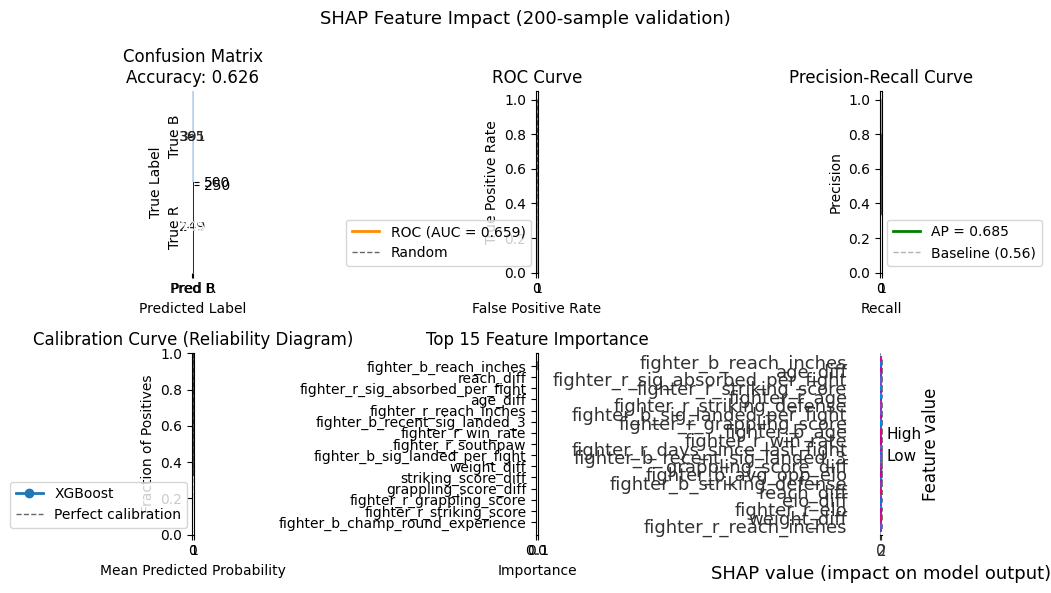


Diagnostic plots rendered above.


In [71]:
# ============================================================
# CELL 12b: Model Evaluation — Visual Diagnostics
# Confusion matrix, ROC, PR curve, calibration, feature importance, SHAP
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, precision_recall_curve,
    auc, average_precision_score, accuracy_score
)
from sklearn.calibration import calibration_curve

# ── Layout ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle('XGBoost Model — Evaluation Diagnostics', fontsize=16, fontweight='bold', y=1.02)
fig.tight_layout(pad=5.0)

# ── 1. Confusion Matrix ────────────────────────────────────
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred B', 'Pred R'],
            yticklabels=['True B', 'True R'],
            ax=axes[0, 0])
axes[0, 0].set_title(f'Confusion Matrix\nAccuracy: {accuracy_score(y_val, y_pred):.3f}')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# ── 2. ROC Curve ───────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(alpha=0.3)

# ── 3. Precision-Recall Curve ──────────────────────────────
precision, recall, _ = precision_recall_curve(y_val, y_prob)
ap = average_precision_score(y_val, y_prob)
baseline_pr = y_val.mean()
axes[0, 2].plot(recall, precision, color='green', lw=2, label=f'AP = {ap:.3f}')
axes[0, 2].axhline(y=baseline_pr, color='gray', linestyle='--', lw=1,
                   alpha=0.6, label=f'Baseline ({baseline_pr:.2f})')
axes[0, 2].set_xlim([0.0, 1.0])
axes[0, 2].set_ylim([0.0, 1.05])
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Precision-Recall Curve')
axes[0, 2].legend(loc='lower left')
axes[0, 2].grid(alpha=0.3)

# ── 4. Calibration Curve ───────────────────────────────────
prob_true, prob_pred = calibration_curve(y_val, y_prob, n_bins=10, strategy='uniform')
axes[1, 0].plot(prob_pred, prob_true, marker='o', lw=2, label='XGBoost')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Perfect calibration')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.0])
axes[1, 0].set_xlabel('Mean Predicted Probability')
axes[1, 0].set_ylabel('Fraction of Positives')
axes[1, 0].set_title('Calibration Curve (Reliability Diagram)')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(alpha=0.3)

# ── 5. Feature Importance (Top 15) ─────────────────────────
imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=True).tail(15)

axes[1, 1].barh(imp_df['feature'], imp_df['importance'], color='steelblue')
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Top 15 Feature Importance')
axes[1, 1].grid(alpha=0.3, axis='x')

# ── 6. SHAP Beeswarm (fallback to XGBoost importance) ─────
try:
    import shap
    X_val_sample = X_val.sample(min(200, len(X_val)), random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_val_sample)
    shap.summary_plot(shap_values, X_val_sample, feature_names=feature_cols,
                      show=False, plot_size=(8, 6))
    shap_fig = plt.gcf()
    shap_fig.suptitle('SHAP Feature Impact (200-sample validation)', fontsize=13)
    print('SHAP beeswarm rendered.')
except Exception as e:
    from xgboost import plot_importance
    axes[1, 2].remove()
    ax_imp = fig.add_subplot(2, 3, 6)
    plot_importance(model.get_booster(), max_num_features=15, ax=ax_imp, importance_type='weight')
    ax_imp.set_title(f'XGBoost Importance (SHAP unavailable)')

plt.show()

print('\n' + '='*60)
print('Diagnostic plots rendered above.')
print('='*60)




In [72]:
# ============================================================
# CELL 12c: Comparison — Filter to fights >= 2005 only
# Pre-2005 data still feeds ELO/stats (Cells 5-6 run on all data)
# Only train/eval split excludes pre-2005 fights
# ============================================================

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

# Filter: keep only fights from 2005 onward
model_df_2005 = model_df[model_df['DATE'] >= '2005-01-01'].copy()
print(f"Fights >= 2005: {len(model_df_2005)} (out of {len(model_df)} total)")
print(f"Fights removed (pre-2005): {len(model_df) - len(model_df_2005)}")

# Temporal split (same 80/20 as Cell 10)
model_df_2005 = model_df_2005.sort_values('DATE').reset_index(drop=True)
split_idx_2005 = int(len(model_df_2005) * 0.8)

train_df_2005 = model_df_2005.iloc[:split_idx_2005]
val_df_2005   = model_df_2005.iloc[split_idx_2005:]

X_train_2005 = train_df_2005[feature_cols]
y_train_2005 = train_df_2005['target']
X_val_2005   = val_df_2005[feature_cols]
y_val_2005   = val_df_2005['target']

print(f"\n2005+ Train: {len(train_df_2005)} fights  ({train_df_2005['DATE'].min().date()} \u2192 {train_df_2005['DATE'].max().date()})")
print(f"2005+ Val:   {len(val_df_2005)} fights  ({val_df_2005['DATE'].min().date()} \u2192 {val_df_2005['DATE'].max().date()})")

# Train XGBoost (same hyperparameters as Cell 11)
import xgboost as xgb

model_2005 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
)

model_2005.fit(
    X_train_2005, y_train_2005,
    eval_set=[(X_train_2005, y_train_2005), (X_val_2005, y_val_2005)],
    verbose=100,
)

print(f"\nBest iteration (2005+): {model_2005.best_iteration}")
print(f"Best validation logloss (2005+): {model_2005.best_score:.4f}")

# Evaluate
y_pred_2005 = (model_2005.predict_proba(X_val_2005)[:, 1] >= 0.55).astype(int)
y_prob_2005 = model_2005.predict_proba(X_val_2005)[:, 1]

acc_2005 = accuracy_score(y_val_2005, y_pred_2005)
auc_2005 = roc_auc_score(y_val_2005, y_prob_2005)

print(f"\n2005+ Validation Accuracy: {acc_2005:.4f}")
print(f"2005+ Validation AUC-ROC:  {auc_2005:.4f}")
print(f"\n2005+ Confusion Matrix:")
print(confusion_matrix(y_val_2005, y_pred_2005))
print(f"\n2005+ Classification Report:")
print(classification_report(y_val_2005, y_pred_2005, target_names=['fighter_b', 'fighter_r']))

# Baseline: predict fighter with higher ELO
val_elo_diff_2005 = model_df_2005.loc[val_df_2005.index, 'elo_diff']
baseline_correct_2005 = ((val_elo_diff_2005 > 0) & (y_val_2005 == 1)) | ((val_elo_diff_2005 < 0) & (y_val_2005 == 0))
baseline_acc_2005 = baseline_correct_2005.sum() / len(y_val_2005)
print(f"\n2005+ Baseline (higher ELO wins): {baseline_acc_2005:.4f}")

# Side-by-side comparison
print(f"\n{'='*60}")
print('Performance Comparison: All Data vs Post-2005 Only')
print(f"{'='*60}")
print(f'  {"Metric":<25} {"All Data":<12} {"Post-2005":<12} {"Delta":<12}')
print(f'  {"─"*25} {"─"*12} {"─"*12} {"─"*12}')
print(f'  {"Accuracy":<25} {accuracy:.4f}       {acc_2005:.4f}       {acc_2005 - accuracy:+.4f}')
print(f'  {"AUC-ROC":<25}  {roc_auc:.4f}       {auc_2005:.4f}       {auc_2005 - roc_auc:+.4f}')
print(f'  {"Baseline (ELO)":<25} {baseline_acc:.4f}       {baseline_acc_2005:.4f}       {baseline_acc_2005 - baseline_acc:+.4f}')
print(f'  {"Best logloss":<25}  {model.best_score:.4f}       {model_2005.best_score:.4f}       {model_2005.best_score - model.best_score:+.4f}')
print(f'  {"Train size":<25} {len(train_df):<12} {len(train_df_2005):<12}')
print(f'  {"Val size":<25}  {len(val_df):<12} {len(val_df_2005):<12}')
print()

# Show how many unique fights were removed by year
pre_2005 = model_df[model_df['DATE'] < '2005-01-01']
print(f"Pre-2005 breakdown:")
print(pre_2005['DATE'].dt.year.value_counts().sort_index().to_string())


Fights >= 2005: 8117 (out of 8547 total)
Fights removed (pre-2005): 430

2005+ Train: 6493 fights  (2005-02-05 → 2023-03-18)
2005+ Val:   1624 fights  (2023-03-25 → 2026-05-16)
[0]	validation_0-logloss:0.64988	validation_1-logloss:0.69947
[100]	validation_0-logloss:0.49481	validation_1-logloss:0.65311
[147]	validation_0-logloss:0.45175	validation_1-logloss:0.65218

Best iteration (2005+): 127
Best validation logloss (2005+): 0.6516

2005+ Validation Accuracy: 0.6213
2005+ Validation AUC-ROC:  0.6601

2005+ Confusion Matrix:
[[367 353]
 [262 642]]

2005+ Classification Report:
              precision    recall  f1-score   support

   fighter_b       0.58      0.51      0.54       720
   fighter_r       0.65      0.71      0.68       904

    accuracy                           0.62      1624
   macro avg       0.61      0.61      0.61      1624
weighted avg       0.62      0.62      0.62      1624


2005+ Baseline (higher ELO wins): 0.5406

Performance Comparison: All Data vs Post-2005 O

# Age as main predictor?

## Cell 14 — SHAP Dependence Plot: `age_diff`

### What this does
Computes SHAP values for the **post-2005 XGBoost model** (`model_2005`) on the
post-2005 validation set (`X_val_2005`) and plots a **SHAP dependence plot**
for the `age_diff` feature.

Each point is one fight:
- **x-axis**: the raw `age_diff` value (`fighter_r_age - fighter_b_age`)
  — positive means red-corner fighter is older, negative means younger.
- **y-axis**: the SHAP value for `age_diff` — this is the feature's impact on
  the model's log-odds prediction.
  - Positive → pushes prediction toward **red wins**.
  - Negative → pushes prediction toward **blue wins**.
- **Color**: the feature that most strongly **interacts** with `age_diff` at
  that point (auto-selected by SHAP). If the color gradient runs vertically,
  the age effect depends on that other feature.

### How to interpret
- **Slope**: If SHAP values trend upward as `age_diff` increases, the model
  thinks older-red fighters are more likely to win (and vice versa).
- **Spread at a given x value**: If there's wide vertical scatter at a fixed
  `age_diff`, it means the model's age effect is **context-dependent** —
  moderated by other features (the coloring reveals which one).
- **Color pattern**: A strong color gradient (e.g., red dots at top, blue at
  bottom) means the interacting feature largely determines *when* age matters.

### What it tells you
- Whether the model treats age as **monotonic** (always favors older or
  younger) or **nonlinear** (e.g., a moderate age gap helps, but a large one
  hurts).
- Which other feature(s) **mediate** the age effect — e.g., does age only
  matter when fighters have similar ELO? Or when reach is equal?


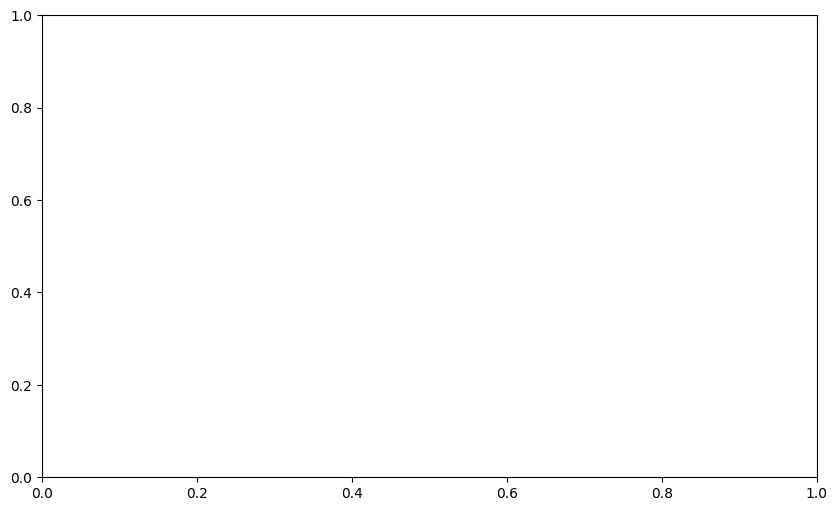

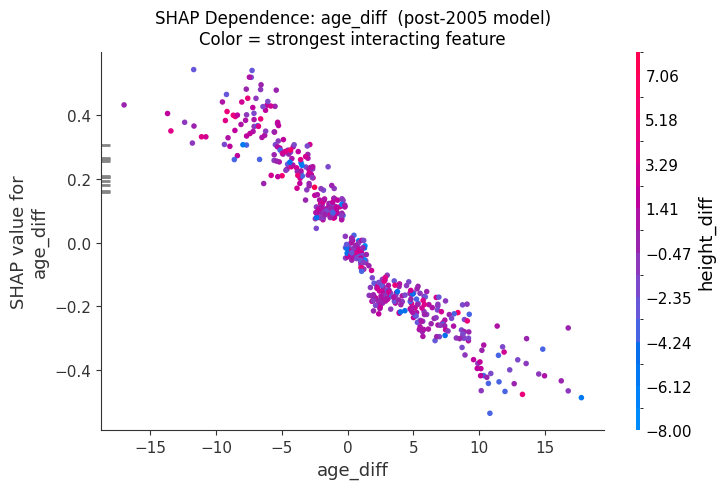


Top 5 features interacting with age_diff:
  fighter_r_age              0.6680
  fighter_b_age              0.6216
  num_fights_diff            0.5107
  fighter_r_num_fights       0.3381
  champ_exp_diff             0.3297


In [73]:
# ============================================================
# CELL 14: SHAP Dependence Plot — age_diff (Post-2005 model)
# ============================================================
import shap
import matplotlib.pyplot as plt

# Reuse model_2005 and X_val_2005 from Cell 12c
explainer = shap.TreeExplainer(model_2005)

# Sample for speed (if needed)
X_shap = X_val_2005.sample(min(500, len(X_val_2005)), random_state=42)
shap_values = explainer.shap_values(X_shap)

# Dependence plot for age_diff, colored by strongest interaction
fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(
    'age_diff',
    shap_values,
    X_shap,
    feature_names=feature_cols,
    interaction_index='auto',
    show=False,
)
plt.title(
    'SHAP Dependence: age_diff  (post-2005 model)\n'
    'Color = strongest interacting feature'
)
plt.tight_layout()
plt.show()

# Print top interacting features
age_diff_idx = feature_cols.index('age_diff')
age_shap = shap_values[:, age_diff_idx]
correlations = []
for i, col in enumerate(feature_cols):
    if col == 'age_diff':
        continue
    corr = abs(pd.Series(age_shap).corr(pd.Series(X_shap[col].values)))
    correlations.append((col, corr))
correlations.sort(key=lambda x: x[1], reverse=True)

print('\nTop 5 features interacting with age_diff:')
for col, corr in correlations[:5]:
    print(f'  {col:25s}  {corr:.4f}')


## Cell 13 — Inference Demo


In [74]:
# ============================================================
# CELL 13: Inference Demo
# ============================================================

# Global defense averages (same computation as Cell 6)
g_striking_def = 1 - (global_stats['sum_sig_landed'] / global_stats['sum_sig_attempted'])
g_td_def = 1 - (global_stats['sum_td_landed'] / global_stats['sum_td_attempted'])

"""Predict winner for any hypothetical or upcoming fight."""

def predict_fight(fighter_a, fighter_b, fight_date,
                  histories, tott_df, xgb_model,
                  def_striking, def_td,
                  weight_class=None):
    """Return probability that fighter_a wins."""
    elo_a = histories.get(fighter_a, {}).get('elo', 1500)
    elo_b = histories.get(fighter_b, {}).get('elo', 1500)

    feats_a = compute_fighter_features(fighter_a, fight_date,
                                        histories, tott_df,
                                        opponent_elo=elo_b,
                                        weight_class=weight_class)
    feats_b = compute_fighter_features(fighter_b, fight_date,
                                        histories, tott_df,
                                        opponent_elo=elo_a,
                                        weight_class=weight_class)

    row = {}
    for k, v in feats_a.items():
        row[f'fighter_r_{k}'] = v
    for k, v in feats_b.items():
        row[f'fighter_b_{k}'] = v

    # Physical differences
    for attr, dname in [('reach_inches','reach_diff'),
                         ('height_inches','height_diff'),
                         ('weight_lbs','weight_diff')]:
        rv = row.get(f'fighter_r_{attr}')
        bv = row.get(f'fighter_b_{attr}')
        row[dname] = rv - bv if pd.notna(rv) and pd.notna(bv) else np.nan

    # Stance
    def _cs(s):
        if pd.isna(s): return np.nan
        s = str(s).strip().lower()
        return 'southpaw' if 'southpaw' in s else ('orthodox' if 'orthodox' in s else ('switch' if 'switch' in s else np.nan))

    sr, sb = _cs(row.get('fighter_r_stance')), _cs(row.get('fighter_b_stance'))
    row['same_stance'] = 1 if (pd.notna(sr) and pd.notna(sb) and sr == sb) else 0
    row['fighter_r_southpaw'] = 1 if sr == 'southpaw' else 0
    row['fighter_b_southpaw'] = 1 if sb == 'southpaw' else 0

    # Age from DOB
    dob_map = tott_df.set_index('FIGHTER')['DOB'].to_dict()
    for prefix, fname in [('fighter_r_', fighter_a), ('fighter_b_', fighter_b)]:
        dob = dob_map.get(fname)
        row[f'{prefix}age'] = (fight_date - dob).days / 365.25 if pd.notna(dob) else np.nan
    row['age_diff'] = row['fighter_r_age'] - row['fighter_b_age']

    # Opponent-adjusted scores
    def _adj(s_col, d_col, gavg):
        sv, dv = row.get(s_col), row.get(d_col)
        if pd.notna(sv) and pd.notna(dv) and gavg > 0:
            return sv * (dv / gavg)
        return sv

    row['adjusted_striking_r'] = _adj('fighter_r_striking_score', 'fighter_b_striking_defense', def_striking)
    row['adjusted_striking_b'] = _adj('fighter_b_striking_score', 'fighter_r_striking_defense', def_striking)
    row['adjusted_grappling_r'] = _adj('fighter_r_grappling_score', 'fighter_b_td_defense', def_td)
    row['adjusted_grappling_b'] = _adj('fighter_b_grappling_score', 'fighter_r_td_defense', def_td)

    row['elo_diff'] = row['fighter_r_elo'] - row['fighter_b_elo']
    row['striking_score_diff'] = row['fighter_r_striking_score'] - row['fighter_b_striking_score']
    row['grappling_score_diff'] = row['fighter_r_grappling_score'] - row['fighter_b_grappling_score']
    row['num_fights_diff'] = row['fighter_r_num_fights'] - row['fighter_b_num_fights']
    row['champ_exp_diff'] = row['fighter_r_champ_round_experience'] - row['fighter_b_champ_round_experience']

    X_pred = pd.DataFrame([row])[feature_cols]
    prob = xgb_model.predict_proba(X_pred)[0, 1]
    return prob

# ------------------------------------------------------------------
# Demo: predict a hypothetical championship fight
# ------------------------------------------------------------------
demo_fighter_a = 'Islam Makhachev'
demo_fighter_b = 'Charles Oliveira'
demo_date = pd.Timestamp('2026-12-31')

prob = predict_fight(demo_fighter_a, demo_fighter_b, demo_date,
                     fighter_histories, tott_clean, model,
                     g_striking_def, g_td_def,
                     weight_class='Lightweight')

print(f'{"="*60}')
print(f'PREDICTION: {demo_fighter_a} vs {demo_fighter_b}')
print(f'{"="*60}')
print(f'{demo_fighter_a} win probability: {prob:.1%}')
print(f'{demo_fighter_b} win probability: {1-prob:.1%}')
print(f'{"="*60}')

# Fighter ELOs
elo_a = fighter_histories.get(demo_fighter_a, {}).get('elo', 'N/A')
elo_b = fighter_histories.get(demo_fighter_b, {}).get('elo', 'N/A')
print(f'{demo_fighter_a} ELO: {round(elo_a,2)}')
print(f'{demo_fighter_b} ELO: {round(elo_b, 2)}')

print('\nFeature vector columns:')
print(f'  {len(feature_cols)} features')


PREDICTION: Islam Makhachev vs Charles Oliveira
Islam Makhachev win probability: 72.8%
Charles Oliveira win probability: 27.2%
Islam Makhachev ELO: 1789.24
Charles Oliveira ELO: 1671.72

Feature vector columns:
  82 features


# MODEL COMPARISON

## Model Comparison: Random Forest & Logistic Regression

Adding Random Forest and Logistic Regression alongside the existing XGBoost for comparison.
Both require NaN imputation and missing-indicator features (XGBoost handles NaNs natively).
Logistic Regression additionally requires feature scaling.

### Cell 14a: Impute NaN, Add Missing Indicators, Scale for LR

- **Missing indicators**: For every feature with any NaN in X_train, add a binary `{col}_missing` column
- **Imputation**: Fill remaining NaNs with column median (fit on train, transform both)
- **Scaling**: StandardScaler (fit on train, transform both) — only used for Logistic Regression

In [75]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Make clean copies (X_train/X_val from Cell 10 stay untouched for XGBoost)
X_train_imp = X_train.copy()
X_val_imp = X_val.copy()

# Columns with any NaN in training set
nan_cols = [c for c in feature_cols if X_train_imp[c].isna().any()]

# Add missing indicators
for col in nan_cols:
    X_train_imp[f'{col}_missing'] = X_train_imp[col].isna().astype(int)
    X_val_imp[f'{col}_missing']   = X_val_imp[col].isna().astype(int)

feature_cols_imp = list(X_train_imp.columns)
print(f'Features after adding missing indicators: {len(feature_cols_imp)}')
print(f'  Original: {len(feature_cols)}')
print(f'  Indicators added: {len(feature_cols_imp) - len(feature_cols)}')

# Median imputation (fit on train, transform both)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_imp),
    columns=feature_cols_imp,
    index=X_train.index,
)
X_val_imp = pd.DataFrame(
    imputer.transform(X_val_imp),
    columns=feature_cols_imp,
    index=X_val.index,
)

# Scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled   = scaler.transform(X_val_imp)

print(f'Imputation + scaling complete.')
print(f'X_train_imp shape: {X_train_imp.shape}')
print(f'Training NaNs remaining: {X_train_imp.isna().sum().sum()}')

Features after adding missing indicators: 161
  Original: 82
  Indicators added: 79
Imputation + scaling complete.
X_train_imp shape: (6837, 161)
Training NaNs remaining: 0


### Cell 14b: Random Forest

Train a Random Forest on the imputed features (no scaling needed).
Same 80/20 temporal split, same evaluation metrics as XGBoost.

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_imp, y_train)

y_pred_rf = (rf.predict_proba(X_val_imp)[:, 1] >= 0.55).astype(int)
y_prob_rf = rf.predict_proba(X_val_imp)[:, 1]

acc_rf = accuracy_score(y_val, y_pred_rf)
auc_rf = roc_auc_score(y_val, y_prob_rf)

print(f'Random Forest Validation Accuracy: {acc_rf:.4f}')
print(f'Random Forest Validation AUC-ROC:  {auc_rf:.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred_rf))
print(f'\nClassification Report:')
print(classification_report(y_val, y_pred_rf, target_names=['fighter_b', 'fighter_r']))

Random Forest Validation Accuracy: 0.6216
Random Forest Validation AUC-ROC:  0.6604

Confusion Matrix:
[[312 444]
 [203 751]]

Classification Report:
              precision    recall  f1-score   support

   fighter_b       0.61      0.41      0.49       756
   fighter_r       0.63      0.79      0.70       954

    accuracy                           0.62      1710
   macro avg       0.62      0.60      0.59      1710
weighted avg       0.62      0.62      0.61      1710



### Cell 14c: Logistic Regression

Train a Logistic Regression on the imputed + scaled features.
Simple baseline — coefficients directly show feature importance direction.

In [77]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train_scaled, y_train)

y_pred_lr = (lr.predict_proba(X_val_scaled)[:, 1] >= 0.55).astype(int)
y_prob_lr = lr.predict_proba(X_val_scaled)[:, 1]

acc_lr = accuracy_score(y_val, y_pred_lr)
auc_lr = roc_auc_score(y_val, y_prob_lr)

print(f'Logistic Regression Validation Accuracy: {acc_lr:.4f}')
print(f'Logistic Regression Validation AUC-ROC:  {auc_lr:.4f}')
print(f'\nConfusion Matrix:')
print(confusion_matrix(y_val, y_pred_lr))
print(f'\nClassification Report:')
print(classification_report(y_val, y_pred_lr, target_names=['fighter_b', 'fighter_r']))

Logistic Regression Validation Accuracy: 0.5965
Logistic Regression Validation AUC-ROC:  0.6472

Confusion Matrix:
[[484 272]
 [418 536]]

Classification Report:
              precision    recall  f1-score   support

   fighter_b       0.54      0.64      0.58       756
   fighter_r       0.66      0.56      0.61       954

    accuracy                           0.60      1710
   macro avg       0.60      0.60      0.60      1710
weighted avg       0.61      0.60      0.60      1710



### Cell 14d: Side-by-Side Comparison (Full Dataset)

Compare all three models on the same validation set.

In [78]:
from sklearn.metrics import precision_recall_fscore_support

print(f'{"="*70}')
print(f'{"Model Comparison 2014 Full Dataset Validation":^70}')
print(f'{"="*70}')
header = f'{"Model":<20} {"Accuracy":<12} {"AUC-ROC":<12} {"Prec (R)":<12} {"Recall (R)":<12} {"F1 (R)":<12}'
sep    = f'{"-"*20} {"-"*12} {"-"*12} {"-"*12} {"-"*12} {"-"*12}'
print(header)
print(sep)

p_xgb, r_xgb, f1_xgb, _ = precision_recall_fscore_support(y_val, y_pred, labels=[1])
print(f'{"XGBoost":<20} {accuracy:<12.4f} {roc_auc:<12.4f} {p_xgb[0]:<12.4f} {r_xgb[0]:<12.4f} {f1_xgb[0]:<12.4f}')

p_rf, r_rf, f1_rf, _ = precision_recall_fscore_support(y_val, y_pred_rf, labels=[1])
print(f'{"Random Forest":<20} {acc_rf:<12.4f} {auc_rf:<12.4f} {p_rf[0]:<12.4f} {r_rf[0]:<12.4f} {f1_rf[0]:<12.4f}')

p_lr, r_lr, f1_lr, _ = precision_recall_fscore_support(y_val, y_pred_lr, labels=[1])
print(f'{"Logistic Reg":<20} {acc_lr:<12.4f} {auc_lr:<12.4f} {p_lr[0]:<12.4f} {r_lr[0]:<12.4f} {f1_lr[0]:<12.4f}')

print(f'\nBaseline (higher ELO wins): {baseline_acc:.4f}')

            Model Comparison 2014 Full Dataset Validation             
Model                Accuracy     AUC-ROC      Prec (R)     Recall (R)   F1 (R)      
-------------------- ------------ ------------ ------------ ------------ ------------
XGBoost              0.6257       0.6590       0.6432       0.7390       0.6878      
Random Forest        0.6216       0.6604       0.6285       0.7872       0.6989      
Logistic Reg         0.5965       0.6472       0.6634       0.5618       0.6084      

Baseline (higher ELO wins): 0.5386


## Repeat on Post-2005 Subset

Same pipeline (imputation \u2192 RF \u2192 LR \u2192 comparison) but training/evaluating only on fights from 2005 onward,
to see if model performance improves with cleaner modern-era data.

### Cell 15a: Post-2005 — Imputation, RF, LR, and Comparison

In [79]:
# ---- Imputation on 2005+ data ----
X_train_2005_imp = train_df_2005[feature_cols].copy()
X_val_2005_imp   = val_df_2005[feature_cols].copy()
y_train_2005 = train_df_2005['target']
y_val_2005   = val_df_2005['target']

# Missing indicators
nan_cols_2005 = [c for c in feature_cols if X_train_2005_imp[c].isna().any()]
for col in nan_cols_2005:
    X_train_2005_imp[f'{col}_missing'] = X_train_2005_imp[col].isna().astype(int)
    X_val_2005_imp[f'{col}_missing']   = X_val_2005_imp[col].isna().astype(int)

feature_cols_imp_2005 = list(X_train_2005_imp.columns)

# Median imputation
imputer_2005 = SimpleImputer(strategy='median')
X_train_imp_2005 = pd.DataFrame(
    imputer_2005.fit_transform(X_train_2005_imp),
    columns=feature_cols_imp_2005,
    index=X_train_2005_imp.index,
)
X_val_imp_2005 = pd.DataFrame(
    imputer_2005.transform(X_val_2005_imp),
    columns=feature_cols_imp_2005,
    index=X_val_2005_imp.index,
)

# Scaling
scaler_2005 = StandardScaler()
X_train_scaled_2005 = scaler_2005.fit_transform(X_train_imp_2005)
X_val_scaled_2005   = scaler_2005.transform(X_val_imp_2005)

# ---- XGBoost on 2005+ (re-evaluate from Cell 12c) ----
X_val_2005_xgb = val_df_2005[feature_cols]  # clean copy, no extra columns
y_pred_2005 = (model_2005.predict_proba(X_val_2005_xgb)[:, 1] >= 0.55).astype(int)
y_prob_2005 = model_2005.predict_proba(X_val_2005_xgb)[:, 1]
acc_xgb_2005 = accuracy_score(y_val_2005, y_pred_2005)
auc_xgb_2005 = roc_auc_score(y_val_2005, y_prob_2005)

# ---- RF on 2005+ ----
rf_2005 = RandomForestClassifier(
    n_estimators=500, max_depth=10, min_samples_leaf=5,
    random_state=42, n_jobs=-1,
)
rf_2005.fit(X_train_imp_2005, y_train_2005)
y_pred_rf_2005 = (rf_2005.predict_proba(X_val_imp_2005)[:, 1] >= 0.55).astype(int)
y_prob_rf_2005 = rf_2005.predict_proba(X_val_imp_2005)[:, 1]
acc_rf_2005 = accuracy_score(y_val_2005, y_pred_rf_2005)
auc_rf_2005 = roc_auc_score(y_val_2005, y_prob_rf_2005)

print(f'2005+ Random Forest 2014 Acc: {acc_rf_2005:.4f}, AUC: {auc_rf_2005:.4f}')
print(classification_report(y_val_2005, y_pred_rf_2005, target_names=['fighter_b', 'fighter_r']))

# ---- LR on 2005+ ----
lr_2005 = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
lr_2005.fit(X_train_scaled_2005, y_train_2005)
y_pred_lr_2005 = (lr_2005.predict_proba(X_val_scaled_2005)[:, 1] >= 0.55).astype(int)
y_prob_lr_2005 = lr_2005.predict_proba(X_val_scaled_2005)[:, 1]
acc_lr_2005 = accuracy_score(y_val_2005, y_pred_lr_2005)
auc_lr_2005 = roc_auc_score(y_val_2005, y_prob_lr_2005)

print(f'2005+ Logistic Reg 2014 Acc: {acc_lr_2005:.4f}, AUC: {auc_lr_2005:.4f}')
print(classification_report(y_val_2005, y_pred_lr_2005, target_names=['fighter_b', 'fighter_r']))

# ---- Comparison table ----
print(f'/n{"="*70}')
print(f'{"Model Comparison 2014 Post-2005 Validation":^70}')
print(f'{"="*70}')
print(header)
print(sep)

p_xgb2, r_xgb2, f1_xgb2, _ = precision_recall_fscore_support(y_val_2005, y_pred_2005, labels=[1])
print(f'{"XGBoost":<20} {acc_xgb_2005:<12.4f} {auc_xgb_2005:<12.4f} {p_xgb2[0]:<12.4f} {r_xgb2[0]:<12.4f} {f1_xgb2[0]:<12.4f}')

p_rf2, r_rf2, f1_rf2, _ = precision_recall_fscore_support(y_val_2005, y_pred_rf_2005, labels=[1])
print(f'{"Random Forest":<20} {acc_rf_2005:<12.4f} {auc_rf_2005:<12.4f} {p_rf2[0]:<12.4f} {r_rf2[0]:<12.4f} {f1_rf2[0]:<12.4f}')

p_lr2, r_lr2, f1_lr2, _ = precision_recall_fscore_support(y_val_2005, y_pred_lr_2005, labels=[1])
print(f'{"Logistic Reg":<20} {acc_lr_2005:<12.4f} {auc_lr_2005:<12.4f} {p_lr2[0]:<12.4f} {r_lr2[0]:<12.4f} {f1_lr2[0]:<12.4f}')

# Baseline
val_elo_diff_2005 = model_df_2005.loc[val_df_2005.index, 'elo_diff']
baseline_correct_2005 = ((val_elo_diff_2005 > 0) & (y_val_2005 == 1)) | ((val_elo_diff_2005 < 0) & (y_val_2005 == 0))
baseline_acc_2005 = baseline_correct_2005.sum() / len(y_val_2005)
print(f'\nBaseline (higher ELO wins): {baseline_acc_2005:.4f}')

2005+ Random Forest 2014 Acc: 0.6219, AUC: 0.6597
              precision    recall  f1-score   support

   fighter_b       0.60      0.43      0.50       720
   fighter_r       0.63      0.77      0.69       904

    accuracy                           0.62      1624
   macro avg       0.62      0.60      0.60      1624
weighted avg       0.62      0.62      0.61      1624

2005+ Logistic Reg 2014 Acc: 0.6065, AUC: 0.6503
              precision    recall  f1-score   support

   fighter_b       0.55      0.66      0.60       720
   fighter_r       0.67      0.57      0.62       904

    accuracy                           0.61      1624
   macro avg       0.61      0.61      0.61      1624
weighted avg       0.62      0.61      0.61      1624

/n======================================================================
              Model Comparison 2014 Post-2005 Validation              
Model                Accuracy     AUC-ROC      Prec (R)     Recall (R)   F1 (R)      
-----------------

### Cell 15b: Overall Comparison — Full + Post-2005

Final comparison grid showing all three models across both data slices.

In [80]:
print(f'{"="*80}')
print(f'{"OVERALL MODEL COMPARISON":^80}')
print(f'{"="*80}')
print()
print(f'{"Full Dataset (1994-2026)":^80}')
print(f'{"-"*80}')
print(header)
print(sep)
print(f'{"XGBoost":<20} {accuracy:<12.4f} {roc_auc:<12.4f} {p_xgb[0]:<12.4f} {r_xgb[0]:<12.4f} {f1_xgb[0]:<12.4f}')
print(f'{"Random Forest":<20} {acc_rf:<12.4f} {auc_rf:<12.4f} {p_rf[0]:<12.4f} {r_rf[0]:<12.4f} {f1_rf[0]:<12.4f}')
print(f'{"Logistic Reg":<20} {acc_lr:<12.4f} {auc_lr:<12.4f} {p_lr[0]:<12.4f} {r_lr[0]:<12.4f} {f1_lr[0]:<12.4f}')
print(f'\nBaseline (ELO): {baseline_acc:.4f}')
print()
print(f'{"Post-2005 Only":^80}')
print(f'{"-"*80}')
print(header)
print(sep)
print(f'{"XGBoost":<20} {acc_xgb_2005:<12.4f} {auc_xgb_2005:<12.4f} {p_xgb2[0]:<12.4f} {r_xgb2[0]:<12.4f} {f1_xgb2[0]:<12.4f}')
print(f'{"Random Forest":<20} {acc_rf_2005:<12.4f} {auc_rf_2005:<12.4f} {p_rf2[0]:<12.4f} {r_rf2[0]:<12.4f} {f1_rf2[0]:<12.4f}')
print(f'{"Logistic Reg":<20} {acc_lr_2005:<12.4f} {auc_lr_2005:<12.4f} {p_lr2[0]:<12.4f} {r_lr2[0]:<12.4f} {f1_lr2[0]:<12.4f}')
print(f'\nBaseline (ELO): {baseline_acc_2005:.4f}')

                            OVERALL MODEL COMPARISON                            

                            Full Dataset (1994-2026)                            
--------------------------------------------------------------------------------
Model                Accuracy     AUC-ROC      Prec (R)     Recall (R)   F1 (R)      
-------------------- ------------ ------------ ------------ ------------ ------------
XGBoost              0.6257       0.6590       0.6432       0.7390       0.6878      
Random Forest        0.6216       0.6604       0.6285       0.7872       0.6989      
Logistic Reg         0.5965       0.6472       0.6634       0.5618       0.6084      

Baseline (ELO): 0.5386

                                 Post-2005 Only                                 
--------------------------------------------------------------------------------
Model                Accuracy     AUC-ROC      Prec (R)     Recall (R)   F1 (R)      
-------------------- ------------ ------------ ------

# FINE TUNING THRESHOLD to keep red bias under control

## Cell 16: Threshold Tuning

Scans thresholds 0.30–0.70 for each model on both data subsets to find the optimal cutoff.
Compares tuned accuracy vs the current 0.55 default.

In [81]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def find_best_threshold(y_true, y_prob, model_label, thresholds=range(30, 71)):
    best_t, best_acc = 0.5, 0
    results = []
    for t in [x/100 for x in thresholds]:
        y_t = (y_prob >= t).astype(int)
        acc = accuracy_score(y_true, y_t)
        p, r, f1, _ = precision_recall_fscore_support(y_true, y_t, labels=[1])
        results.append({'threshold': t, 'accuracy': acc, 'prec_r': p[0], 'recall_r': r[0], 'f1_r': f1[0]})
        if acc > best_acc:
            best_t, best_acc = t, acc

    best_row = [r for r in results if r['threshold'] == best_t][0]
    def50    = [r for r in results if r['threshold'] == 0.50][0]
    def55    = [r for r in results if r['threshold'] == 0.55][0]

    print(f'\n{model_label}')
    print(f'  Optimal: threshold={best_t:.2f}  acc={best_acc:.4f}  prec(R)={best_row["prec_r"]:.4f}  recall(R)={best_row["recall_r"]:.4f}  f1(R)={best_row["f1_r"]:.4f}')
    print(f'  At 0.50:  acc={def50["accuracy"]:.4f}  prec(R)={def50["prec_r"]:.4f}  recall(R)={def50["recall_r"]:.4f}  f1(R)={def50["f1_r"]:.4f}')
    print(f'  At 0.55:  acc={def55["accuracy"]:.4f}  prec(R)={def55["prec_r"]:.4f}  recall(R)={def55["recall_r"]:.4f}  f1(R)={def55["f1_r"]:.4f}')
    return best_t, best_acc, results

print('='*80)
print('THRESHOLD TUNING RESULTS')
print('='*80)

# ---- Full dataset ----
print(f'\n>>> Full Dataset')
t_xgb,  a_xgb,  _ = find_best_threshold(y_val, y_prob, 'XGBoost')
t_rf,   a_rf,   _ = find_best_threshold(y_val, y_prob_rf, 'Random Forest')
t_lr,   a_lr,   _ = find_best_threshold(y_val, y_prob_lr, 'Logistic Reg')

# ---- Post-2005 ----
print(f'\n>>> Post-2005')
t_xgb5, a_xgb5, _ = find_best_threshold(y_val_2005, y_prob_2005, 'XGBoost')
t_rf5,  a_rf5,  _ = find_best_threshold(y_val_2005, y_prob_rf_2005, 'Random Forest')
t_lr5,  a_lr5,  _ = find_best_threshold(y_val_2005, y_prob_lr_2005, 'Logistic Reg')

# ---- Summary table ----
print(f'\n{"="*80}')
print('SUMMARY — Optimal Threshold vs Default 0.55')
print('='*80)
h = f'{"Model":<25} {"Data":<12} {"Opt T":<8} {"Opt Acc":<12} {"55 Acc":<12} {"Gain":<10}'
print(h)
print(f'{"-"*25} {"-"*12} {"-"*8} {"-"*12} {"-"*12} {"-"*10}')

rows = [
    ('XGBoost', 'Full', t_xgb, a_xgb, accuracy_score(y_val, (y_prob >= 0.55).astype(int))),
    ('Random Forest', 'Full', t_rf, a_rf, accuracy_score(y_val, (y_prob_rf >= 0.55).astype(int))),
    ('Logistic Reg', 'Full', t_lr, a_lr, accuracy_score(y_val, (y_prob_lr >= 0.55).astype(int))),
    ('XGBoost', '2005+', t_xgb5, a_xgb5, accuracy_score(y_val_2005, (y_prob_2005 >= 0.55).astype(int))),
    ('Random Forest', '2005+', t_rf5, a_rf5, accuracy_score(y_val_2005, (y_prob_rf_2005 >= 0.55).astype(int))),
    ('Logistic Reg', '2005+', t_lr5, a_lr5, accuracy_score(y_val_2005, (y_prob_lr_2005 >= 0.55).astype(int))),
]
for model, data, opt_t, opt_acc, acc55 in rows:
    gain = opt_acc - acc55
    print(f'{model:<25} {data:<12} {opt_t:<8.2f} {opt_acc:<12.4f} {acc55:<12.4f} {gain:<+10.4f}')

THRESHOLD TUNING RESULTS

>>> Full Dataset

XGBoost
  Optimal: threshold=0.54  acc=0.6275  prec(R)=0.6382  recall(R)=0.7673  f1(R)=0.6968
  At 0.50:  acc=0.6146  prec(R)=0.6100  recall(R)=0.8574  f1(R)=0.7129
  At 0.55:  acc=0.6257  prec(R)=0.6432  recall(R)=0.7390  f1(R)=0.6878

Random Forest
  Optimal: threshold=0.53  acc=0.6310  prec(R)=0.6238  recall(R)=0.8532  f1(R)=0.7207
  At 0.50:  acc=0.6170  prec(R)=0.6032  recall(R)=0.9161  f1(R)=0.7274
  At 0.55:  acc=0.6216  prec(R)=0.6285  recall(R)=0.7872  f1(R)=0.6989

Logistic Reg
  Optimal: threshold=0.41  acc=0.6263  prec(R)=0.6237  recall(R)=0.8323  f1(R)=0.7131
  At 0.50:  acc=0.6123  prec(R)=0.6511  recall(R)=0.6572  f1(R)=0.6541
  At 0.55:  acc=0.5965  prec(R)=0.6634  recall(R)=0.5618  f1(R)=0.6084

>>> Post-2005

XGBoost
  Optimal: threshold=0.50  acc=0.6318  prec(R)=0.6286  recall(R)=0.8274  f1(R)=0.7144
  At 0.50:  acc=0.6318  prec(R)=0.6286  recall(R)=0.8274  f1(R)=0.7144
  At 0.55:  acc=0.6213  prec(R)=0.6452  recall(R)=0.71

# The Other Model 
Logistic regression – is the Meta the real predictor for fights?

## Cell 17: Rolling Window Meta Analysis

Trains Logistic Regression on sliding 3-year windows (every 6 months) from 2005 onward.
Tracks how each advantage feature's coefficient changes over time.
Shows which types of advantages rose/declined in importance over UFC history.

Building rolling window meta models...
Using 10 advantage features: ['elo_diff', 'striking_score_diff', 'grappling_score_diff', 'num_fights_diff', 'champ_exp_diff', 'reach_diff', 'height_diff', 'age_diff', 'fighter_r_southpaw', 'weight_diff']


Trained 32 window models
Date range: 2009-01-02 to 2024-07-15
Window sizes: 631 - 1537 fights
Window accuracy range: 0.601 to 0.930

Average |coefficient| by feature (higher = more important):
age_diff                0.299734
elo_diff                0.173399
grappling_score_diff    0.164092
weight_diff             0.125918
striking_score_diff     0.116164
num_fights_diff         0.089001
reach_diff              0.086526
height_diff             0.077282
fighter_r_southpaw      0.069320
champ_exp_diff          0.045323


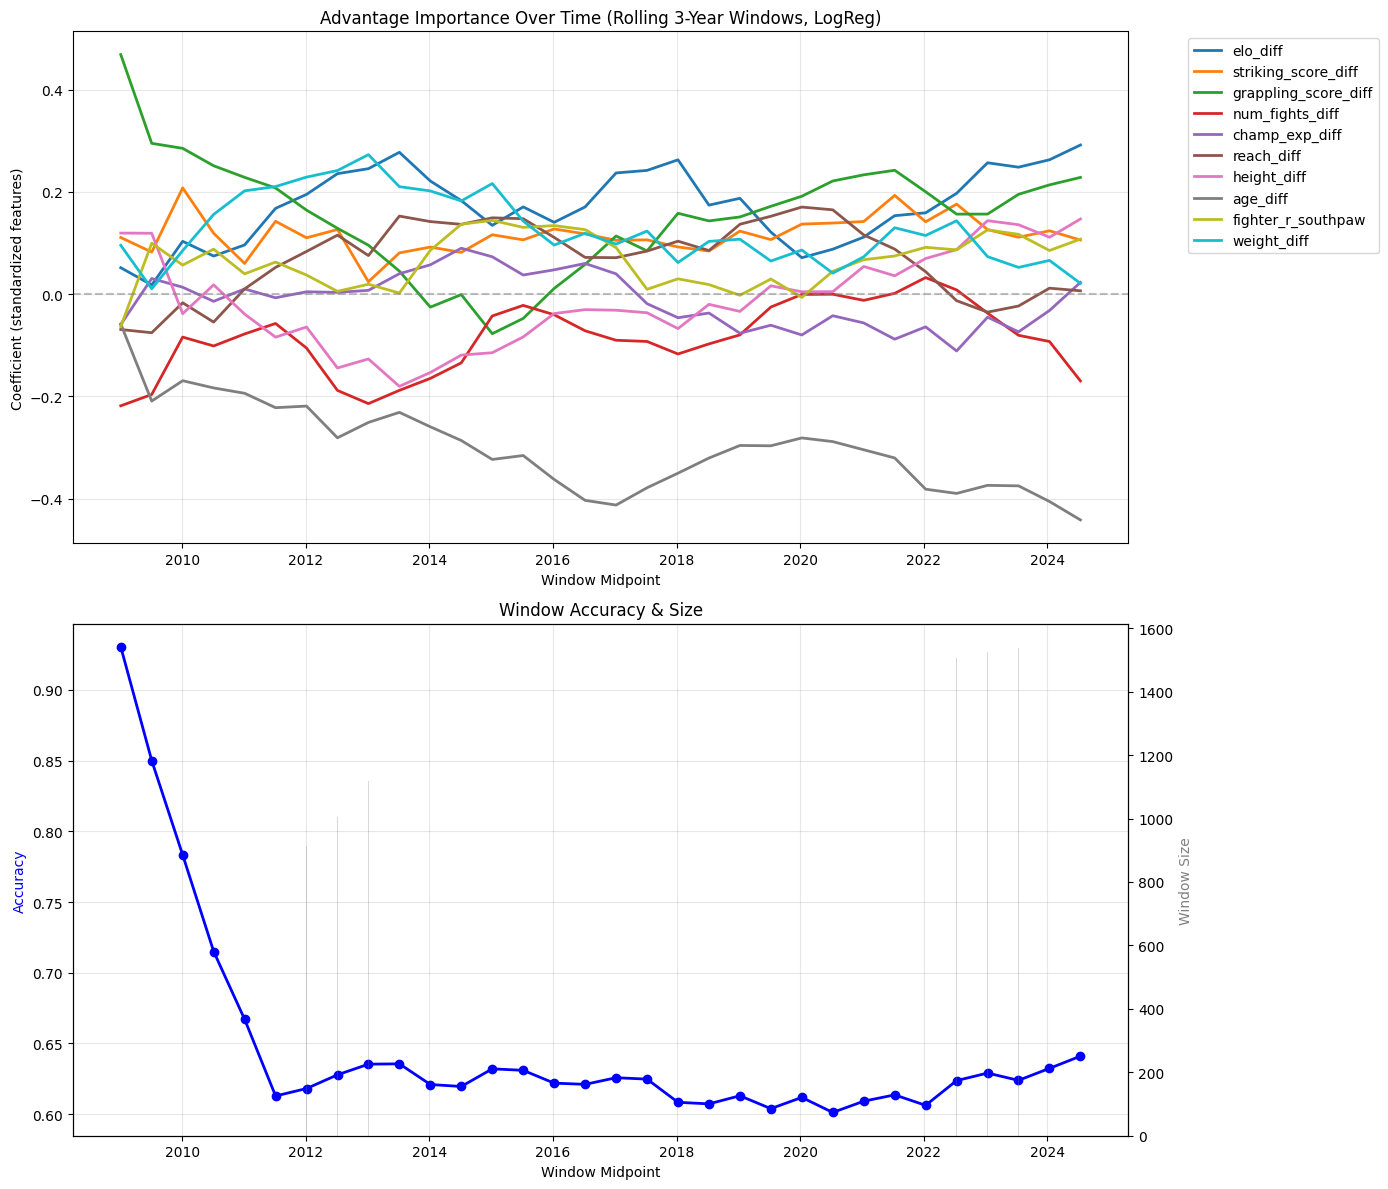

In [82]:
print('Building rolling window meta models...')

advantage_features_cols = [
    'elo_diff', 'striking_score_diff', 'grappling_score_diff',
    'num_fights_diff', 'champ_exp_diff', 'reach_diff',
    'height_diff', 'age_diff', 'fighter_r_southpaw', 'weight_diff'
]

available = [f for f in advantage_features_cols if f in model_df_2005.columns]
print(f'Using {len(available)} advantage features: {available}')

meta_df = model_df_2005.sort_values('DATE').reset_index(drop=True)
dates = meta_df['DATE']

window_size = pd.Timedelta(days=365*3)
step_size = pd.Timedelta(days=183)

window_models = []
window_scalers = []
window_imputers = []
window_midpoints = []
window_sizes = []
window_accs = []

cur = pd.Timestamp('2005-01-01')
end = dates.max()

while cur + window_size <= end:
    mask = (dates >= cur) & (dates < cur + window_size)
    n = mask.sum()
    if n < 200:
        cur += step_size
        continue

    X_sub = meta_df.loc[mask, available].copy()
    y_sub = meta_df.loc[mask, 'target']

    valid = X_sub.dropna(how='all').index
    X_sub = X_sub.loc[valid]
    y_sub = y_sub.loc[valid]

    if y_sub.nunique() < 2:
        cur += step_size
        continue

    imp = SimpleImputer(strategy='median')
    X_imp = imp.fit_transform(X_sub)

    scaler = StandardScaler()
    X_scl = scaler.fit_transform(X_imp)

    lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    lr.fit(X_scl, y_sub)

    window_models.append(lr)
    window_scalers.append(scaler)
    window_imputers.append(imp)
    window_midpoints.append(cur + window_size / 2)
    window_sizes.append(n)

    y_pred = lr.predict(X_scl)
    window_accs.append(accuracy_score(y_sub, y_pred))

    cur += step_size

print(f'Trained {len(window_models)} window models')
print(f'Date range: {window_midpoints[0].date()} to {window_midpoints[-1].date()}')
print(f'Window sizes: {min(window_sizes)} - {max(window_sizes)} fights')
print(f'Window accuracy range: {min(window_accs):.3f} to {max(window_accs):.3f}')

coeff_df = pd.DataFrame(
    [m.coef_[0] for m in window_models],
    columns=available,
    index=window_midpoints
)

print(f'\nAverage |coefficient| by feature (higher = more important):')
print(coeff_df.abs().mean().sort_values(ascending=False).to_string())

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

ax = axes[0]
for col in coeff_df.columns:
    ax.plot(coeff_df.index, coeff_df[col], label=col, linewidth=2)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Window Midpoint')
ax.set_ylabel('Coefficient (standardized features)')
ax.set_title('Advantage Importance Over Time (Rolling 3-Year Windows, LogReg)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)

ax2 = axes[1]
ax2_twin = ax2.twinx()
ax2.plot(window_midpoints, window_accs, 'b-o', label='Accuracy', linewidth=2)
ax2_twin.bar(window_midpoints, window_sizes, alpha=0.3, color='gray', label='Fights')
ax2.set_xlabel('Window Midpoint')
ax2.set_ylabel('Accuracy', color='b')
ax2_twin.set_ylabel('Window Size', color='gray')
ax2.set_title('Window Accuracy & Size')
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Cell 18: Advantage Predictor

Uses the closest rolling window model to decompose a fight prediction into per-advantage contributions.
Shows which fighter has the edge in striking, grappling, experience, reach, etc.

In [84]:
def predict_advantages(fighter_a, fighter_b, fight_date,
                       histories, tott_df,
                       window_models, window_scalers, window_imputers,
                       window_midpoints, advantage_features,
                       weight_class=None):
    """Return per-advantage contributions + overall win prob for fighter_a."""
    fight_date = pd.Timestamp(fight_date)

    idx = np.argmin([abs(m - fight_date) for m in window_midpoints])
    model = window_models[idx]
    scaler = window_scalers[idx]
    imp = window_imputers[idx]

    elo_a = histories.get(fighter_a, {}).get('elo', 1500)
    elo_b = histories.get(fighter_b, {}).get('elo', 1500)

    fa = compute_fighter_features(fighter_a, fight_date, histories, tott_df,
                                  opponent_elo=elo_b, weight_class=weight_class)
    fb = compute_fighter_features(fighter_b, fight_date, histories, tott_df,
                                  opponent_elo=elo_a, weight_class=weight_class)

    row = {}
    row['elo_diff'] = fa['elo'] - fb['elo']
    row['striking_score_diff'] = (fa.get('striking_score') or 0) - (fb.get('striking_score') or 0)
    row['grappling_score_diff'] = (fa.get('grappling_score') or 0) - (fb.get('grappling_score') or 0)
    row['num_fights_diff'] = fa['num_fights'] - fb['num_fights']
    row['champ_exp_diff'] = (fa.get('champ_round_experience') or 0) - (fb.get('champ_round_experience') or 0)
    row['reach_diff'] = (fa.get('reach_inches') or np.nan) - (fb.get('reach_inches') or np.nan)
    row['height_diff'] = (fa.get('height_inches') or np.nan) - (fb.get('height_inches') or np.nan)
    row['weight_diff'] = (fa.get('weight_lbs') or np.nan) - (fb.get('weight_lbs') or np.nan)

    def _sp(s):
        return 1 if pd.notna(s) and 'southpaw' in str(s).lower() else 0
    row['fighter_r_southpaw'] = _sp(fa.get('stance'))

    dob_map = tott_df.set_index('FIGHTER')['DOB'].to_dict()
    dob_a, dob_b = dob_map.get(fighter_a), dob_map.get(fighter_b)
    age_a = (fight_date - dob_a).days / 365.25 if pd.notna(dob_a) else np.nan
    age_b = (fight_date - dob_b).days / 365.25 if pd.notna(dob_b) else np.nan
    row['age_diff'] = age_a - age_b

    X_row = pd.DataFrame([row])[advantage_features]
    X_imp = imp.transform(X_row)
    X_scl = scaler.transform(X_imp)

    contribs = {}
    for i, col in enumerate(advantage_features):
        contribs[col] = model.coef_[0][i] * X_scl[0][i]

    prob = model.predict_proba(X_scl)[0, 1]
    return contribs, prob, window_midpoints[idx]

# ---- Demo ----
demo_a, demo_b, demo_date = 'Islam Makhachev', 'Charles Oliveira', pd.Timestamp('2026-12-31')

contributions, prob, wm_date = predict_advantages(
    demo_a, demo_b, demo_date,
    fighter_histories, tott_clean,
    window_models, window_scalers, window_imputers, window_midpoints,
    available, weight_class='Lightweight'
)

print(f'{"="*60}')
print(f'ADVANTAGE ANALYSIS')
print(f'{"="*60}')
print(f'{demo_a} vs {demo_b}')
print(f'Date: {demo_date.date()}  |  Meta window: {wm_date.date()}')
print()

adv_labels = {
    'elo_diff': 'Skill (ELO)',
    'striking_score_diff': 'Striking',
    'grappling_score_diff': 'Grappling',
    'num_fights_diff': 'Experience',
    'champ_exp_diff': 'Big-fight exp',
    'reach_diff': 'Reach',
    'height_diff': 'Height',
    'weight_diff': 'Weight',
    'age_diff': 'Age',
    'fighter_r_southpaw': 'Southpaw',
}

for col, val in sorted(contributions.items(), key=lambda x: -abs(x[1])):
    label = adv_labels.get(col, col)
    if abs(val) < 0.001:
        adv = '--'
    elif val > 0:
        adv = f'{demo_a}'
    else:
        adv = f'{demo_b}'
    print(f'  {label:<16s}  {val:+.4f}  \u2192  {adv}')

print()
print(f'  {demo_a} win probability: {prob:.2%}')
print(f'  (based on LogReg from {wm_date.date()} window)')

ADVANTAGE ANALYSIS
Islam Makhachev vs Charles Oliveira
Date: 2026-12-31  |  Meta window: 2024-07-15

  Skill (ELO)       +0.5807  →  Islam Makhachev
  Experience        +0.4523  →  Islam Makhachev
  Southpaw          +0.2338  →  Islam Makhachev
  Age               +0.2222  →  Islam Makhachev
  Grappling         +0.1128  →  Islam Makhachev
  Striking          +0.0523  →  Islam Makhachev
  Weight            +0.0346  →  Islam Makhachev
  Big-fight exp     -0.0250  →  Charles Oliveira
  Reach             -0.0083  →  Charles Oliveira
  Height            -0.0002  →  --

  Islam Makhachev win probability: 87.02%
  (based on LogReg from 2024-07-15 window)
